In [1]:
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr, kruskal
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

In [2]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_clinical = clinical_df.select_dtypes(include=['number']).columns

features_df = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# features_df = pd.read_csv(r"D:\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

🔵 CORRELATION BETWEEN CLINICAL DATA AND IMAGE FEATURES

In [3]:
scaler = StandardScaler()

clinical_scaled = pd.DataFrame(scaler.fit_transform(clinical_df[numeric_clinical]),
                               columns=clinical_df[numeric_clinical].columns,
                               index=clinical_df[numeric_clinical].index)

features_scaled = pd.DataFrame(scaler.fit_transform(features_df[numeric_features]),
                               columns=features_df[numeric_features].columns,
                               index=features_df[numeric_features].index)

In [16]:
clinical_column = 'Beta2 microglobulin (mg/l)'

spearman_corr = {}

for col in numeric_features:
    valid_idx = features_scaled[col].notna() & clinical_scaled[clinical_column].notna()
    corr, p_value = spearmanr(features_scaled[col][valid_idx], clinical_scaled[clinical_column][valid_idx])
    spearman_corr[col] = {'spearman_corr': corr, 'p_value': p_value, 'significant': p_value < 0.05}

spearman_df = pd.DataFrame(spearman_corr).T
spearman_df = spearman_df.sort_values(by='spearman_corr', ascending=False)

# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
spearman_df

,spearman_corr,p_value,significant
original_glcm_Idm,0.505298,0.00001,True
original_glcm_Id,0.504476,0.00001,True
gradient_gldm_LowGrayLevelEmphasis,0.498429,0.000013,True
gradient_glrlm_LongRunLowGrayLevelEmphasis,0.486518,0.000022,True
gradient_glrlm_LowGrayLevelRunEmphasis,0.485951,0.000023,True
...,...,...,...
original_glrlm_RunLengthNonUniformityNormalized,-0.476945,0.000034,True
original_glcm_DifferenceEntropy,-0.477913,0.000033,True
original_glrlm_ShortRunEmphasis,-0.478571,0.000032,True
original_glcm_DifferenceAverage,-0.482882,0.000026,True


🔵 MUTUAL INFORMATION BETWEEN SELECTED BIOMARKER AND ALL IMAGE FEATURES

In [5]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_column = 'Beta2 microglobulin (mg/l)'   # Serum M-protein quantity (g/l)

features_df = pd.read_csv(r"D:\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns


mutual_info = {}

for col in numeric_features:
    valid_idx = features_df[col].notna() & clinical_df[clinical_column].notna()

    X = features_df[[col]][valid_idx]
    y = clinical_df[clinical_column][valid_idx]

    mi = mutual_info_regression(X, y)[0]
    mutual_info[col] = {'MI': mi}

mi_df = pd.DataFrame(mutual_info).T
mi_df = mi_df.sort_values(by='MI', ascending=False)

# pd.set_option('display.max_rows', None)
pd.reset_option('display.max_rows')
mi_df

,MI
original_glrlm_RunVariance,0.374666
original_gldm_LargeDependenceEmphasis,0.351175
original_gldm_DependenceNonUniformityNormalized,0.327315
gradient_gldm_LargeDependenceLowGrayLevelEmphasis,0.324057
original_glcm_SumSquares,0.262021
...,...
gradient_glszm_SizeZoneNonUniformity,0.000000
gradient_glszm_LargeAreaHighGrayLevelEmphasis,0.000000
gradient_gldm_LargeDependenceHighGrayLevelEmphasis,0.000000
gradient_ngtdm_Coarseness,0.000000


🔵 BOXPLOT FOR STAGE AND SELECTED IMAGE FEATURES

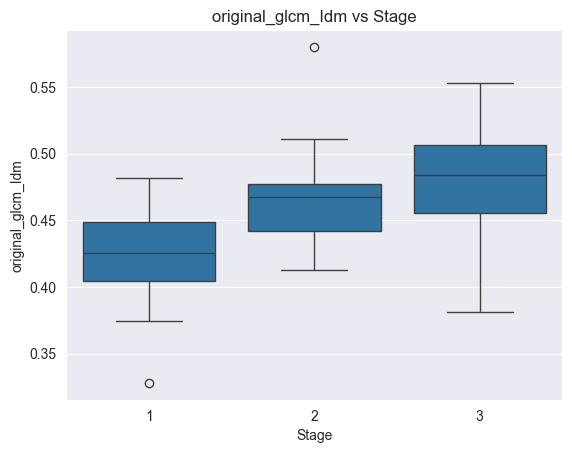

In [4]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

img_feature = "original_glcm_Idm"  # original_firstorder_Range -> useless

data = pd.concat([features_df[img_feature], clinical_df['Stage']], axis=1).dropna()
sns.boxplot(x='Stage', y=img_feature, data=data)
plt.xlabel('Stage')
plt.ylabel(img_feature)
plt.title(f'{img_feature} vs Stage')
plt.show()

🔵 LASSO REGULARIZATION FOR FEATURE SELECTION

In [8]:
from sklearn.linear_model import Lasso

valid_idx = clinical_scaled['Beta2 microglobulin (mg/l)'].notna()

lasso = Lasso(alpha=0.01)
X = features_scaled[numeric_features][valid_idx]
y = clinical_scaled['Beta2 microglobulin (mg/l)'][valid_idx]
lasso.fit(X, y)

print("R^2 score Lasso:", lasso.score(X, y))
feature_weights = pd.Series(lasso.coef_, index=X.columns)
feature_weights

R^2 score Lasso: 0.8317476996272839


n_lesions                        -0.485925
original_shape_Elongation        -0.000000
original_shape_Flatness          -0.000000
original_shape_LeastAxisLength    0.179611
original_shape_MajorAxisLength    1.022180
                                    ...   
gradient_ngtdm_Busyness           0.000000
gradient_ngtdm_Coarseness        -0.013310
gradient_ngtdm_Complexity        -0.000000
gradient_ngtdm_Contrast          -0.000000
gradient_ngtdm_Strength          -0.000000
Length: 201, dtype: float64

In [13]:
combined_feature = X.dot(feature_weights)
corr, p_value = spearmanr(combined_feature, y)
print(f"Spearmanova korelácia kombinovaného príznaku: {corr:.3f}")
print(f"P-hodnota: {p_value:.3e} | Significant {p_value < 0.05}")

Spearmanova korelácia kombinovaného príznaku: 0.750
P-hodnota: 1.154e-13 | Significant True


In [14]:
combined_feature = X.sum(axis=1)
corr, p_value = spearmanr(combined_feature, y)
print(f"Spearmanova korelácia kombinovaného príznaku (váhy=1): {corr:.3f}")
print(f"P-hodnota: {p_value:.3e} | Significant {p_value < 0.05}")

Spearmanova korelácia kombinovaného príznaku (váhy=1): -0.159
P-hodnota: 1.914e-01 | Significant False


🔵 BOXPLOT BETWEEN STAGE AND EVERY FEATURE

Kruskal-Wallis: n_lesions -> H = 2.161, p = 0.3395 => Significant: False


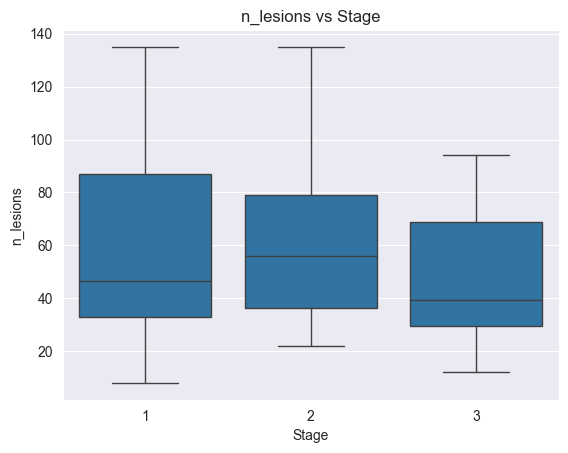

Kruskal-Wallis: original_shape_Elongation -> H = 0.093, p = 0.9548 => Significant: False


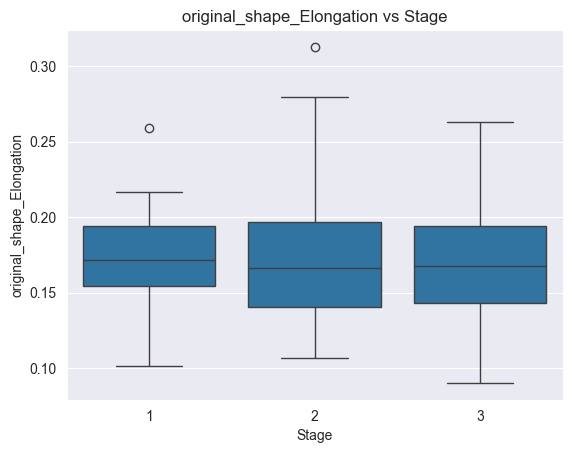

Kruskal-Wallis: original_shape_Flatness -> H = 2.343, p = 0.3099 => Significant: False


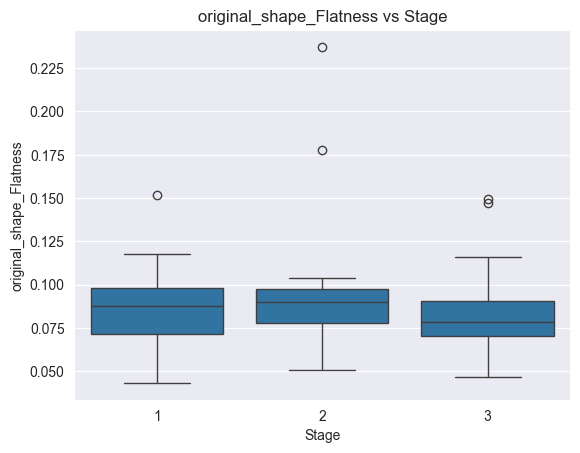

Kruskal-Wallis: original_shape_LeastAxisLength -> H = 0.394, p = 0.8214 => Significant: False


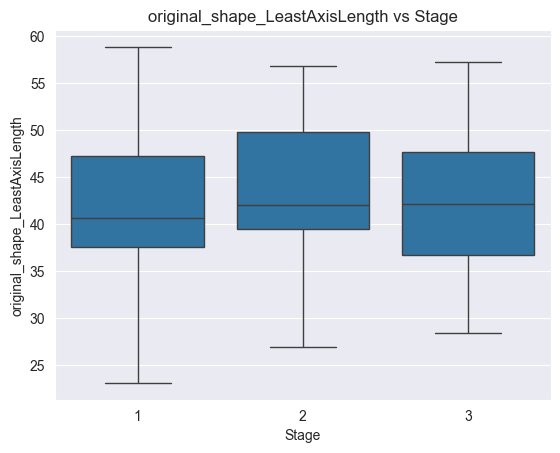

Kruskal-Wallis: original_shape_MajorAxisLength -> H = 0.434, p = 0.8050 => Significant: False


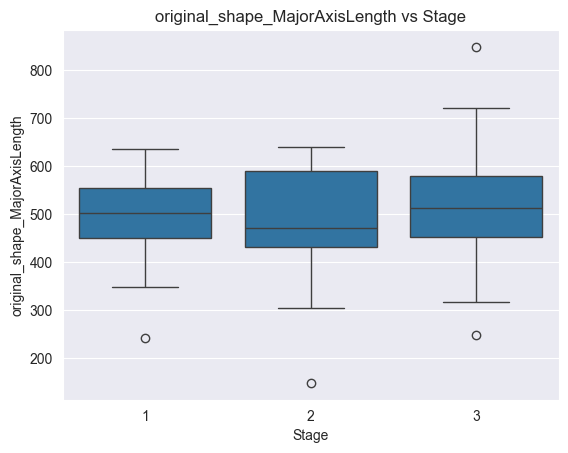

Kruskal-Wallis: original_shape_Maximum2DDiameterColumn -> H = 2.476, p = 0.2900 => Significant: False


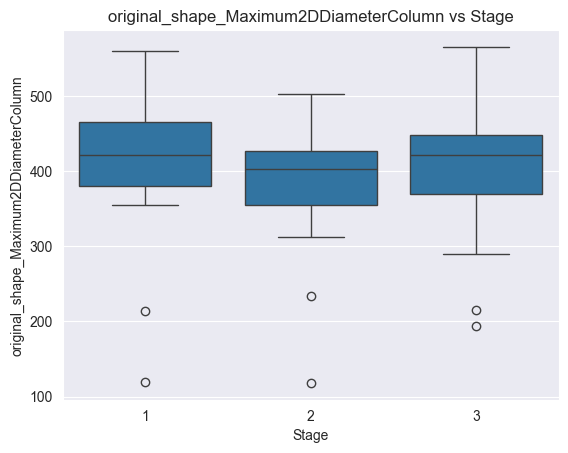

Kruskal-Wallis: original_shape_Maximum2DDiameterRow -> H = 2.122, p = 0.3461 => Significant: False


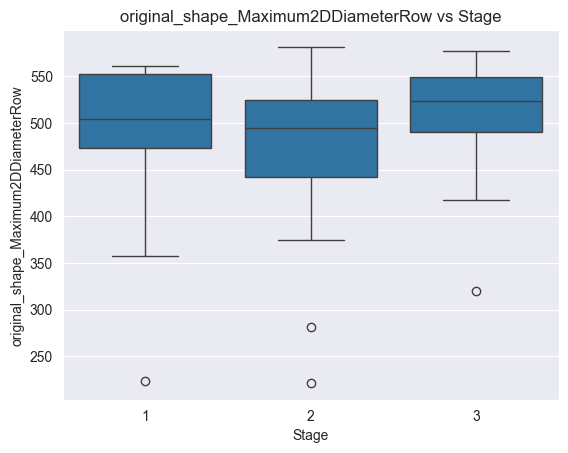

Kruskal-Wallis: original_shape_Maximum2DDiameterSlice -> H = 2.424, p = 0.2976 => Significant: False


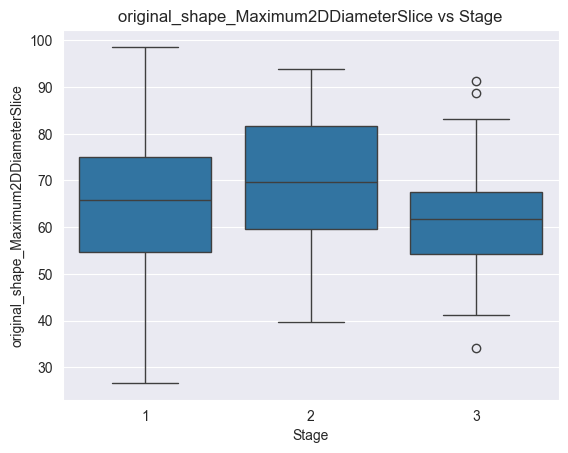

Kruskal-Wallis: original_shape_Maximum3DDiameter -> H = 3.434, p = 0.1796 => Significant: False


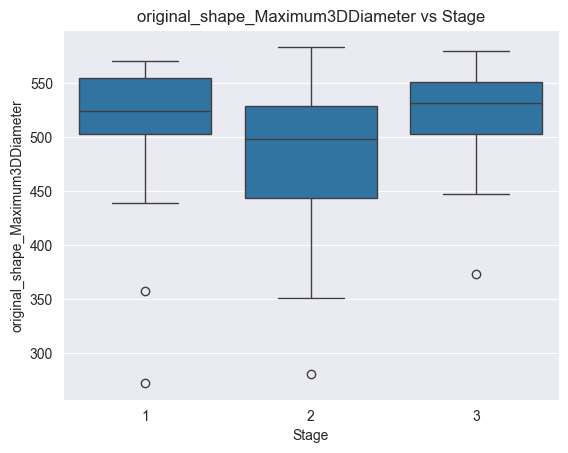

Kruskal-Wallis: original_shape_MeshVolume -> H = 1.368, p = 0.5045 => Significant: False


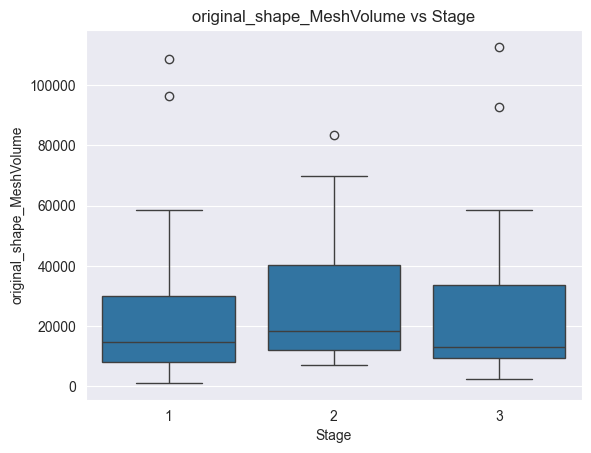

Kruskal-Wallis: original_shape_MinorAxisLength -> H = 0.085, p = 0.9584 => Significant: False


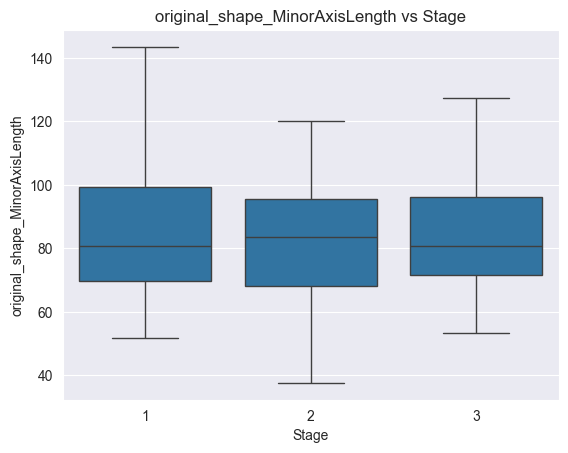

Kruskal-Wallis: original_shape_Sphericity -> H = 2.436, p = 0.2958 => Significant: False


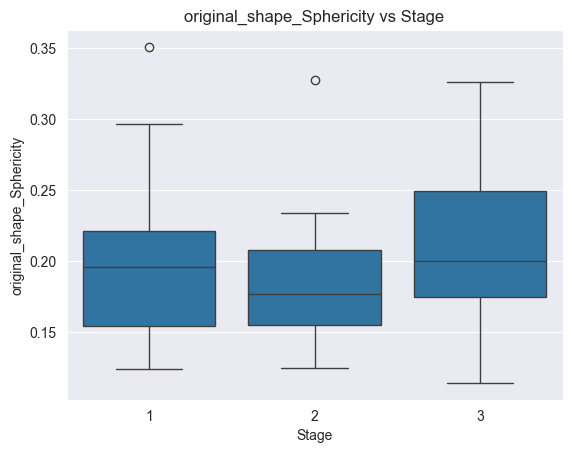

Kruskal-Wallis: original_shape_SurfaceArea -> H = 1.611, p = 0.4468 => Significant: False


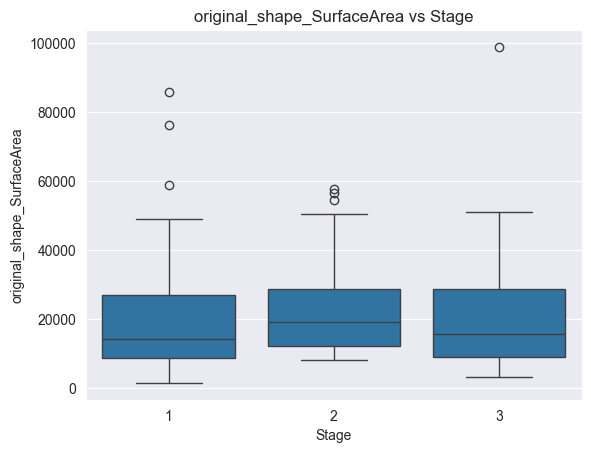

Kruskal-Wallis: original_shape_SurfaceVolumeRatio -> H = 0.977, p = 0.6136 => Significant: False


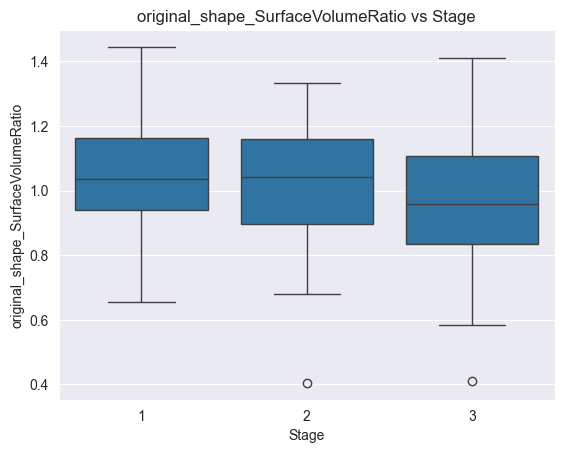

Kruskal-Wallis: original_shape_VoxelVolume -> H = 1.314, p = 0.5184 => Significant: False


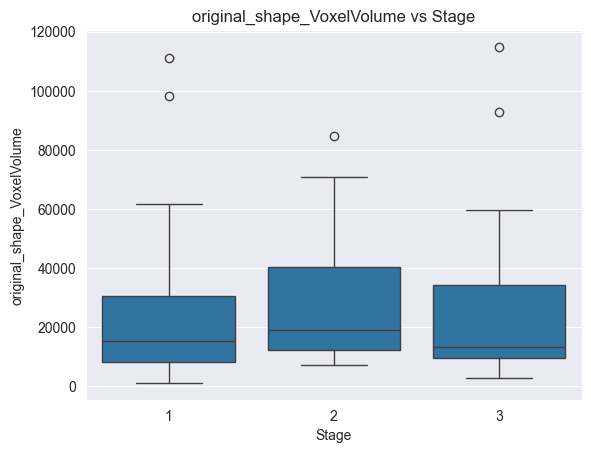

Kruskal-Wallis: original_firstorder_10Percentile -> H = 2.750, p = 0.2528 => Significant: False


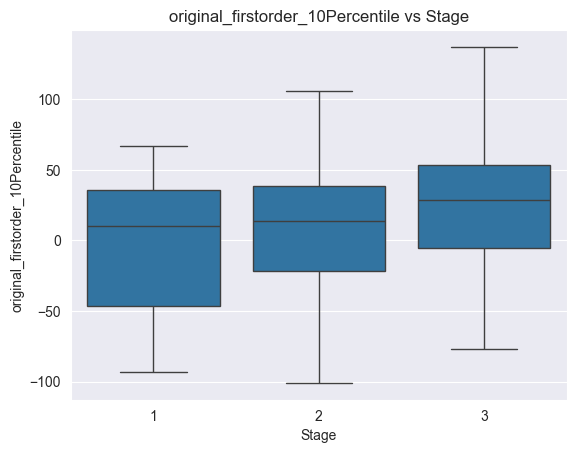

Kruskal-Wallis: original_firstorder_90Percentile -> H = 4.952, p = 0.0841 => Significant: False


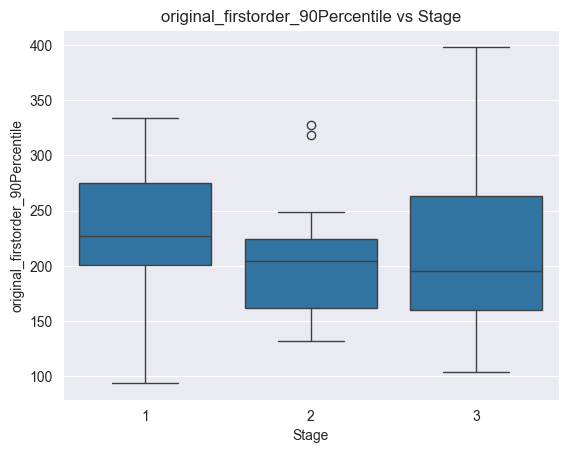

Kruskal-Wallis: original_firstorder_Energy -> H = 0.499, p = 0.7791 => Significant: False


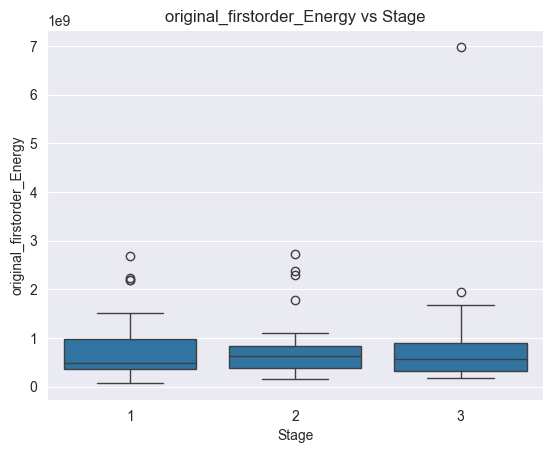

Kruskal-Wallis: original_firstorder_Entropy -> H = 17.402, p = 0.0002 => Significant: True


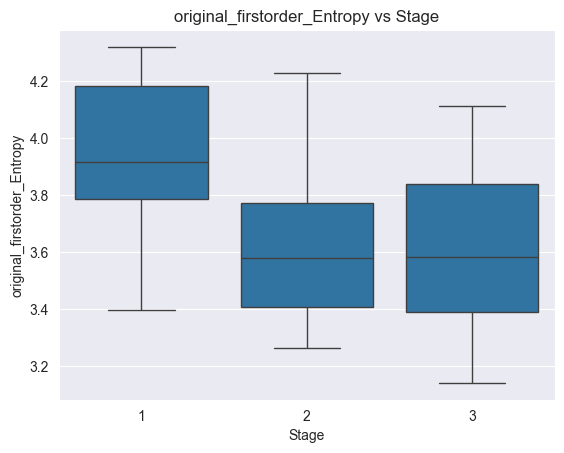

Kruskal-Wallis: original_firstorder_InterquartileRange -> H = 17.545, p = 0.0002 => Significant: True


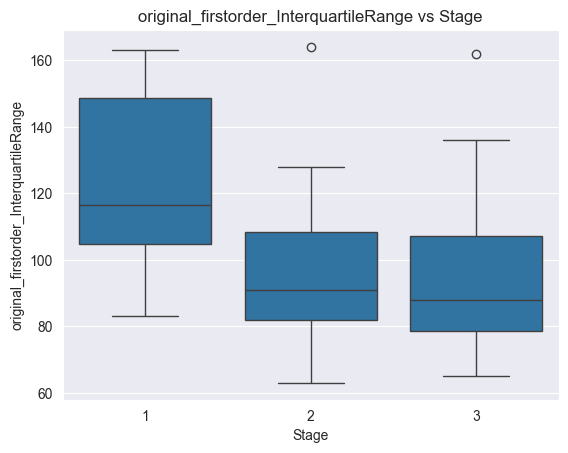

Kruskal-Wallis: original_firstorder_Kurtosis -> H = 17.490, p = 0.0002 => Significant: True


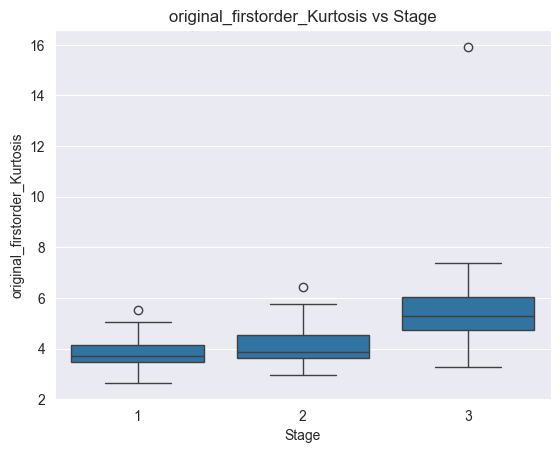

Kruskal-Wallis: original_firstorder_Maximum -> H = 2.939, p = 0.2301 => Significant: False


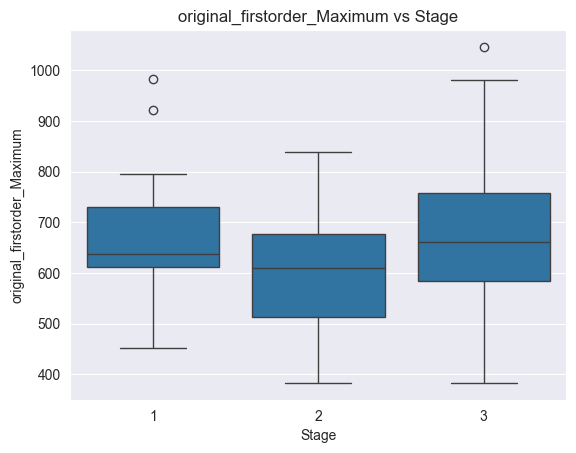

Kruskal-Wallis: original_firstorder_MeanAbsoluteDeviation -> H = 16.873, p = 0.0002 => Significant: True


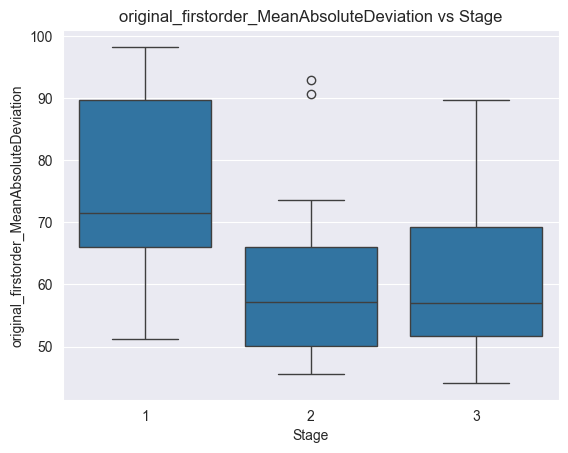

Kruskal-Wallis: original_firstorder_Mean -> H = 0.864, p = 0.6494 => Significant: False


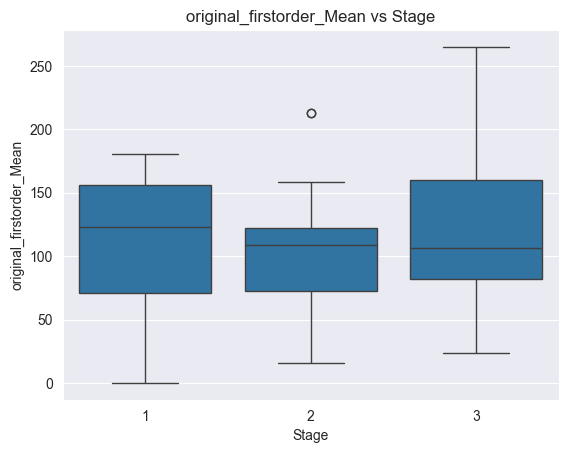

Kruskal-Wallis: original_firstorder_Median -> H = 0.496, p = 0.7802 => Significant: False


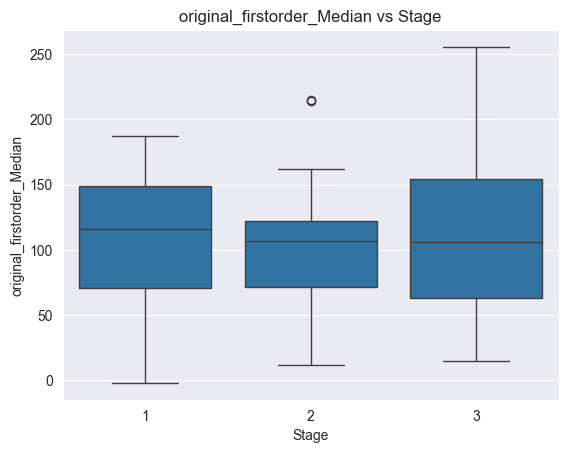

Kruskal-Wallis: original_firstorder_Minimum -> H = 3.949, p = 0.1388 => Significant: False


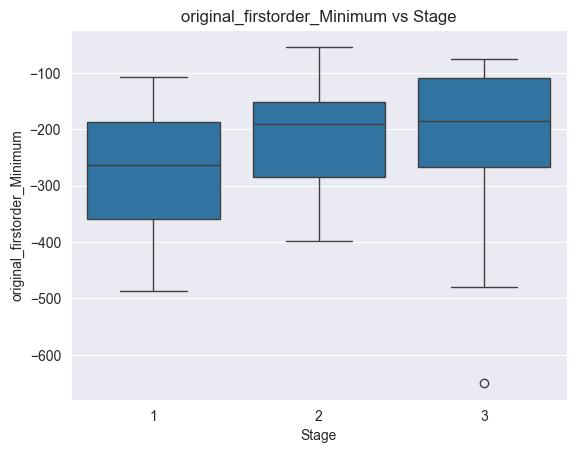

Kruskal-Wallis: original_firstorder_Range -> H = 4.534, p = 0.1036 => Significant: False


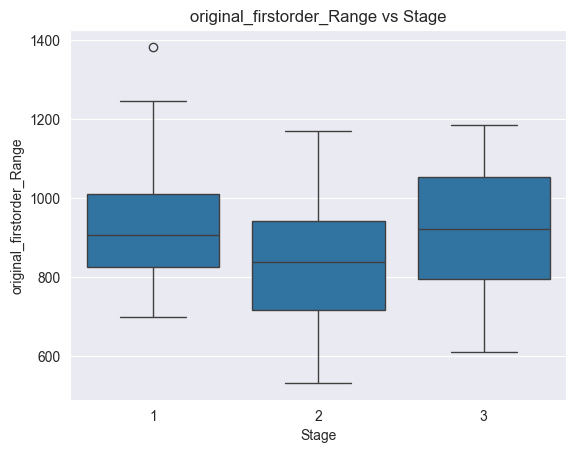

Kruskal-Wallis: original_firstorder_RobustMeanAbsoluteDeviation -> H = 17.160, p = 0.0002 => Significant: True


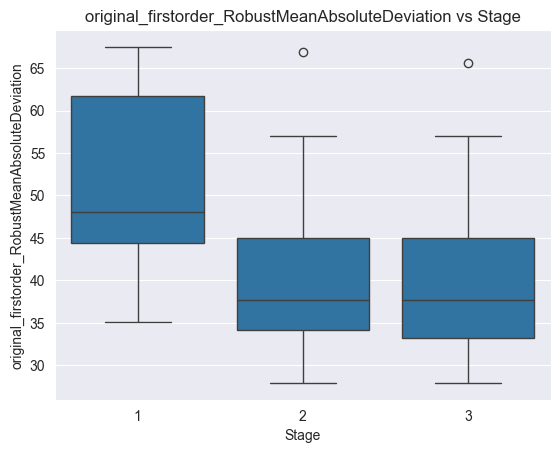

Kruskal-Wallis: original_firstorder_RootMeanSquared -> H = 3.161, p = 0.2058 => Significant: False


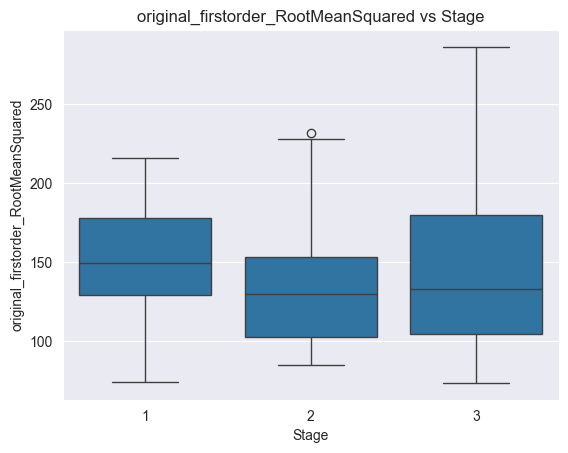

Kruskal-Wallis: original_firstorder_Skewness -> H = 8.915, p = 0.0116 => Significant: True


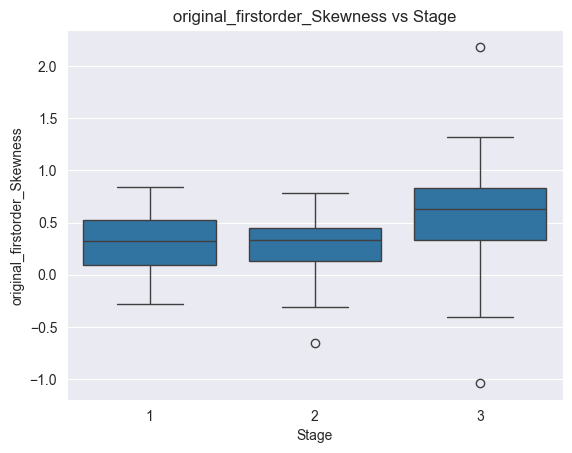

Kruskal-Wallis: original_firstorder_TotalEnergy -> H = 0.440, p = 0.8024 => Significant: False


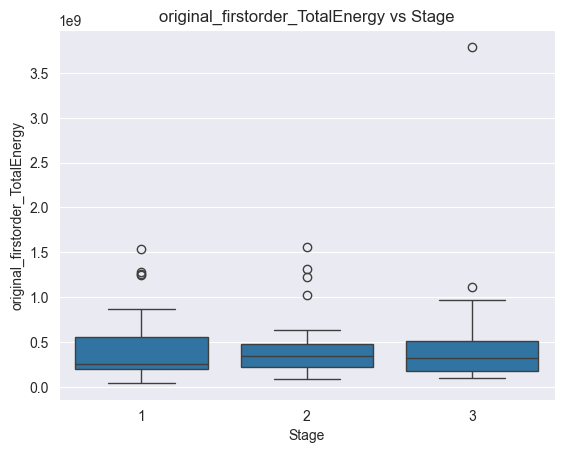

Kruskal-Wallis: original_firstorder_Uniformity -> H = 17.891, p = 0.0001 => Significant: True


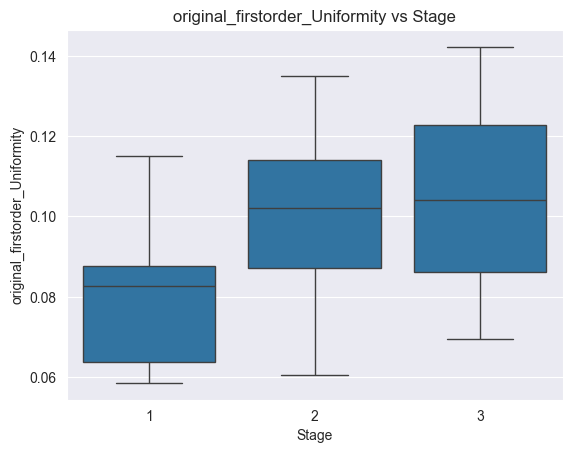

Kruskal-Wallis: original_firstorder_Variance -> H = 15.369, p = 0.0005 => Significant: True


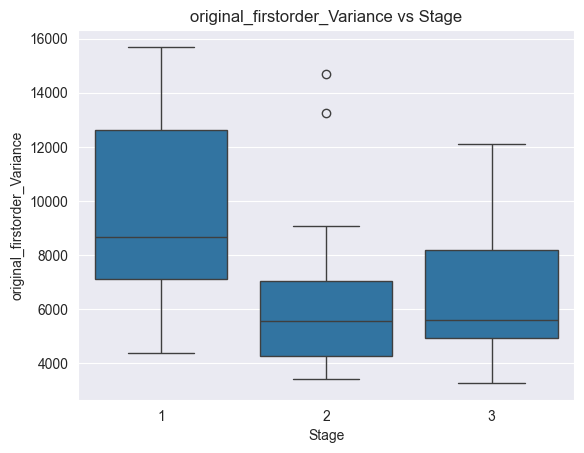

Kruskal-Wallis: original_glcm_Autocorrelation -> H = 6.432, p = 0.0401 => Significant: True


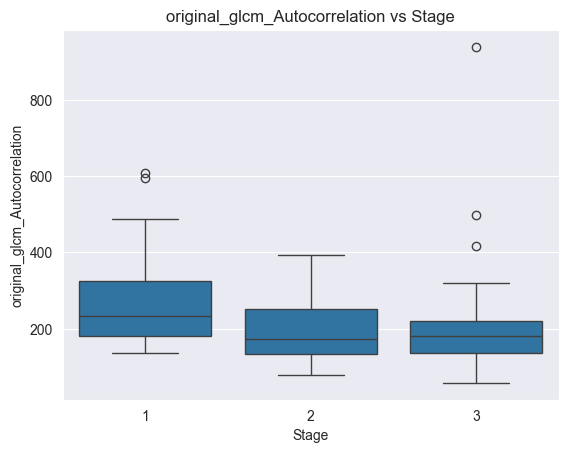

Kruskal-Wallis: original_glcm_ClusterProminence -> H = 12.309, p = 0.0021 => Significant: True


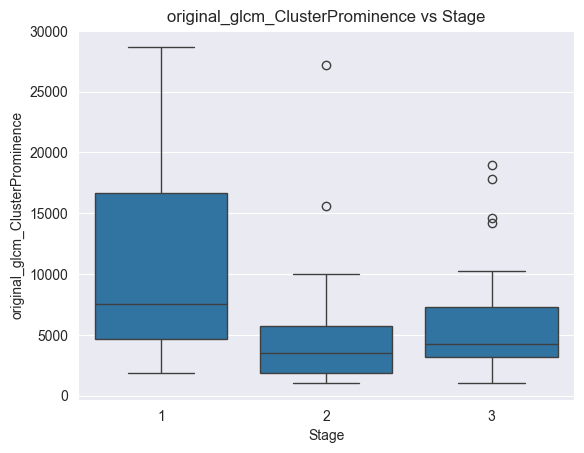

Kruskal-Wallis: original_glcm_ClusterShade -> H = 1.554, p = 0.4598 => Significant: False


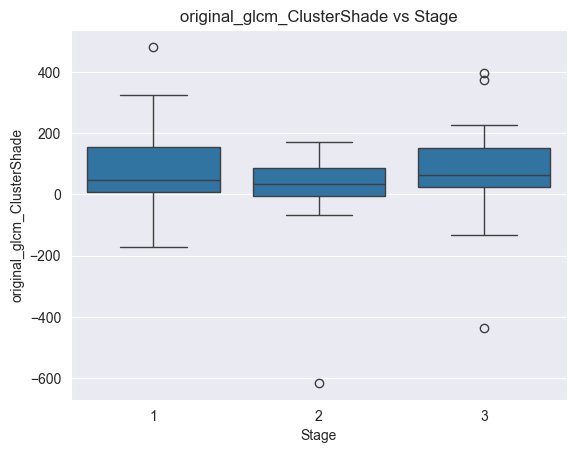

Kruskal-Wallis: original_glcm_ClusterTendency -> H = 14.117, p = 0.0009 => Significant: True


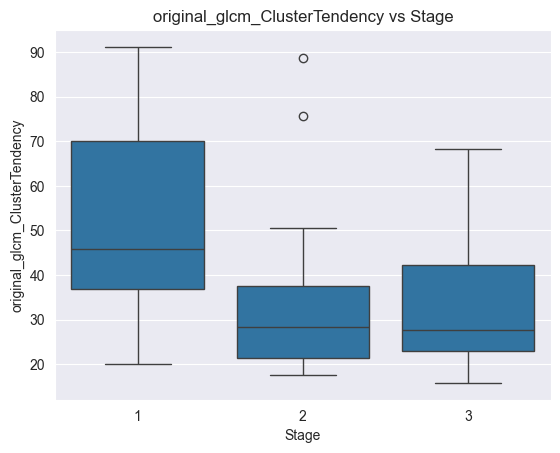

Kruskal-Wallis: original_glcm_Contrast -> H = 18.999, p = 0.0001 => Significant: True


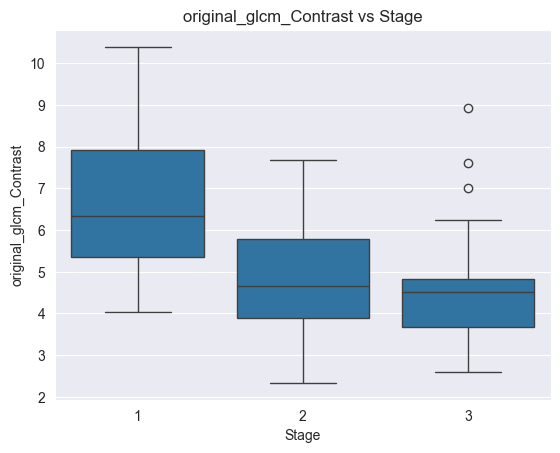

Kruskal-Wallis: original_glcm_Correlation -> H = 1.773, p = 0.4121 => Significant: False


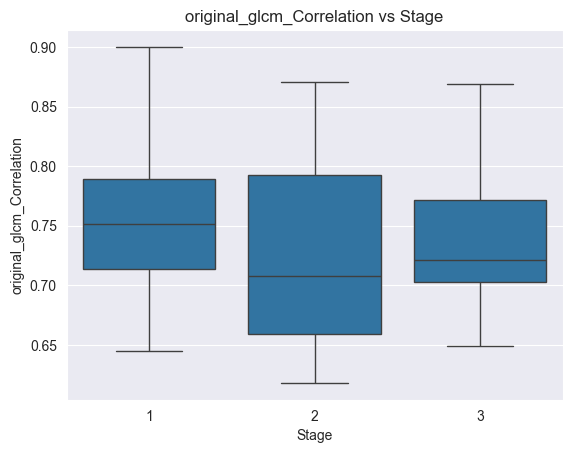

Kruskal-Wallis: original_glcm_DifferenceAverage -> H = 19.864, p = 0.0000 => Significant: True


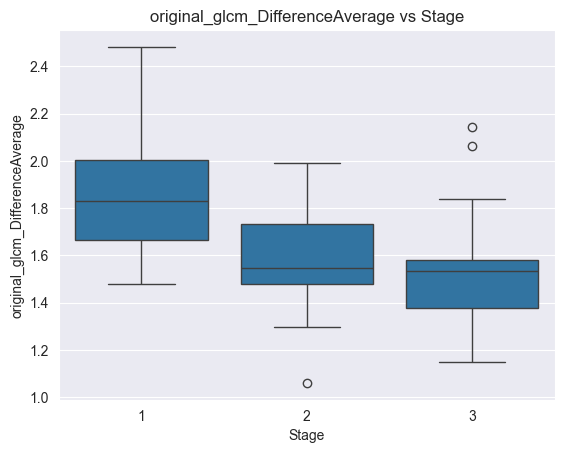

Kruskal-Wallis: original_glcm_DifferenceEntropy -> H = 20.095, p = 0.0000 => Significant: True


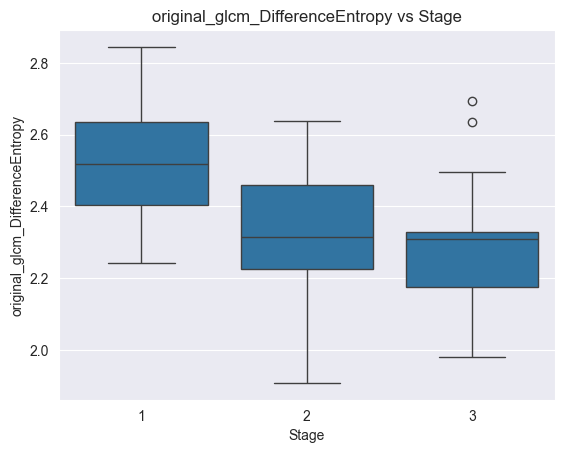

Kruskal-Wallis: original_glcm_DifferenceVariance -> H = 16.562, p = 0.0003 => Significant: True


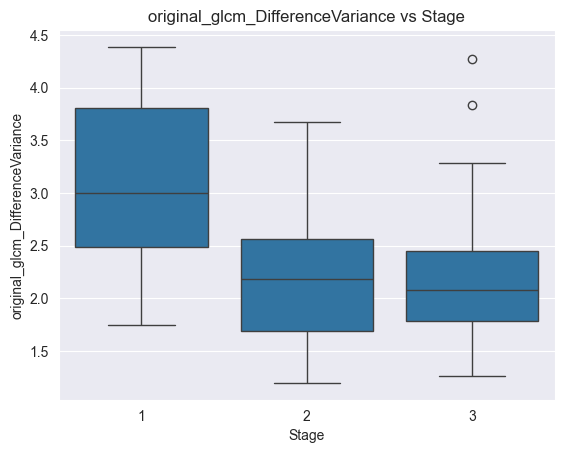

Kruskal-Wallis: original_glcm_Id -> H = 20.906, p = 0.0000 => Significant: True


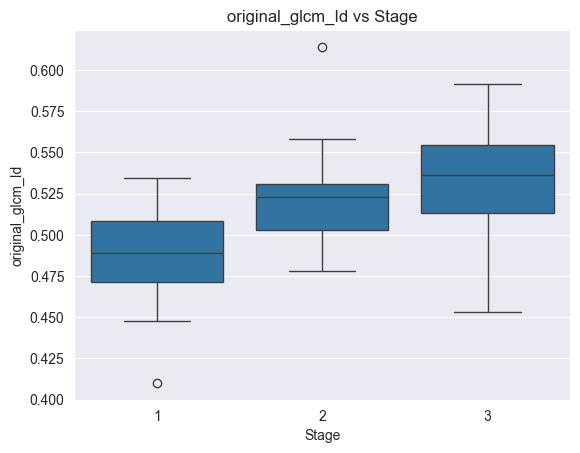

Kruskal-Wallis: original_glcm_Idm -> H = 21.003, p = 0.0000 => Significant: True


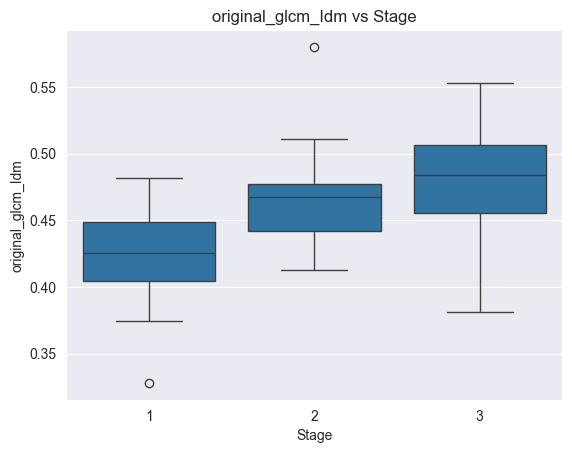

Kruskal-Wallis: original_glcm_Idmn -> H = 7.955, p = 0.0187 => Significant: True


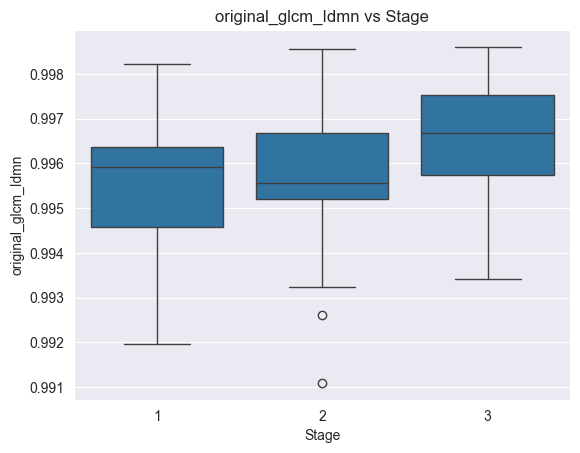

Kruskal-Wallis: original_glcm_Idn -> H = 9.323, p = 0.0095 => Significant: True


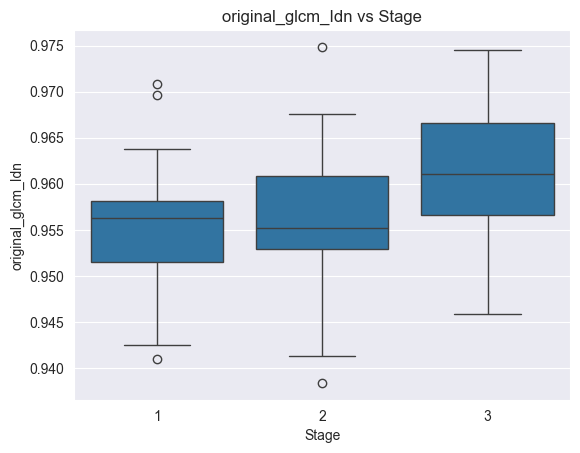

Kruskal-Wallis: original_glcm_Imc1 -> H = 1.178, p = 0.5549 => Significant: False


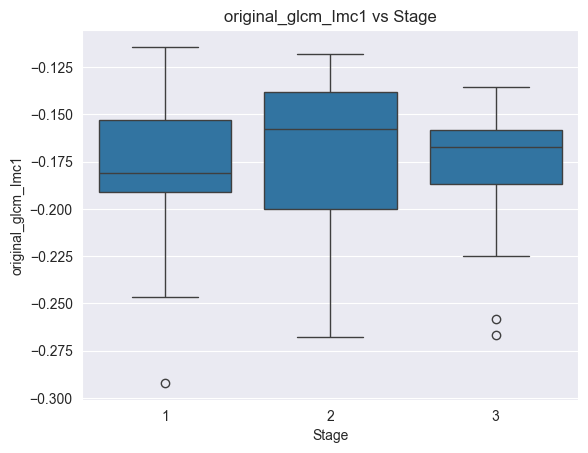

Kruskal-Wallis: original_glcm_Imc2 -> H = 3.982, p = 0.1365 => Significant: False


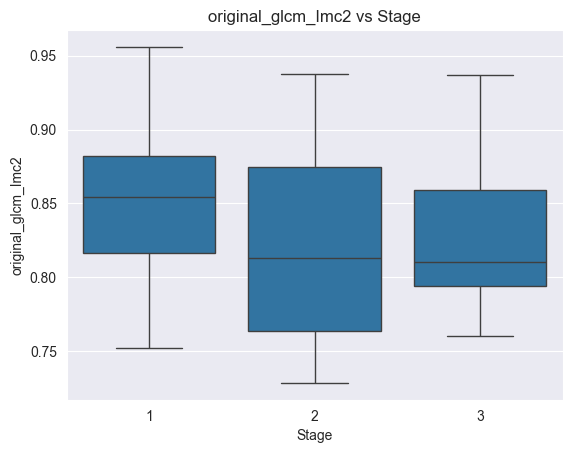

Kruskal-Wallis: original_glcm_InverseVariance -> H = 19.050, p = 0.0001 => Significant: True


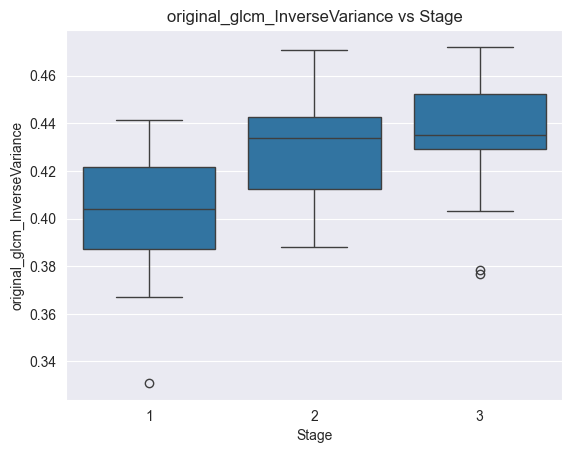

Kruskal-Wallis: original_glcm_JointAverage -> H = 5.679, p = 0.0585 => Significant: False


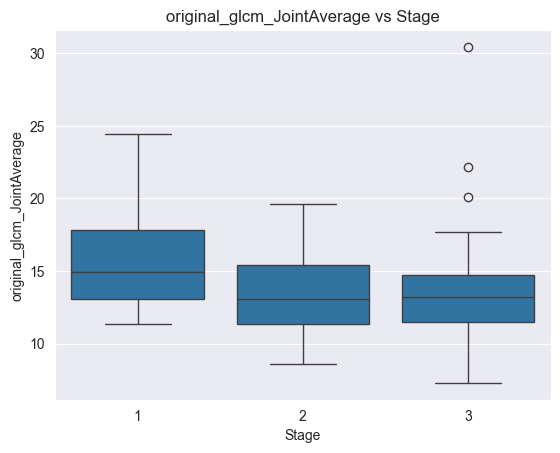

Kruskal-Wallis: original_glcm_JointEnergy -> H = 19.779, p = 0.0001 => Significant: True


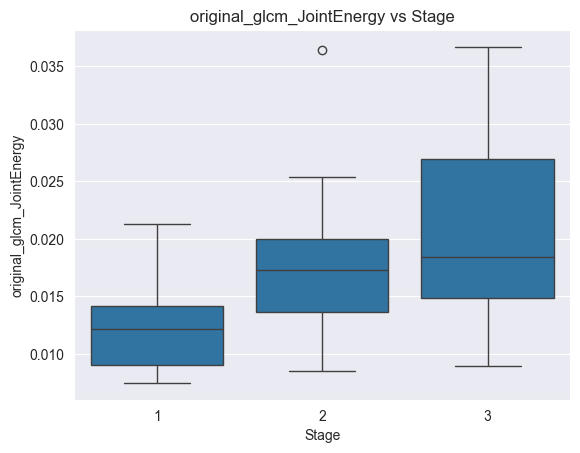

Kruskal-Wallis: original_glcm_JointEntropy -> H = 19.547, p = 0.0001 => Significant: True


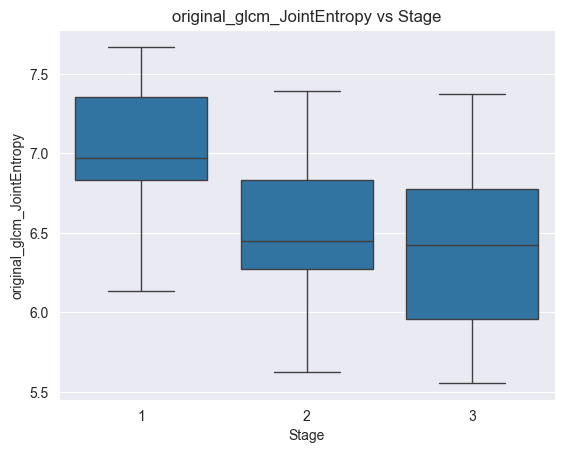

Kruskal-Wallis: original_glcm_MCC -> H = 3.244, p = 0.1976 => Significant: False


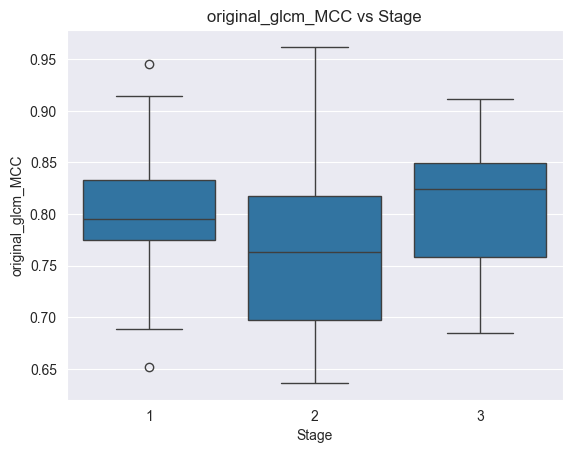

Kruskal-Wallis: original_glcm_MaximumProbability -> H = 21.219, p = 0.0000 => Significant: True


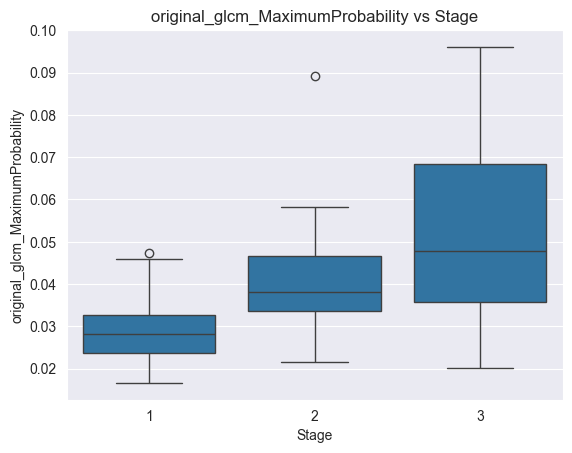

Kruskal-Wallis: original_glcm_SumAverage -> H = 5.679, p = 0.0585 => Significant: False


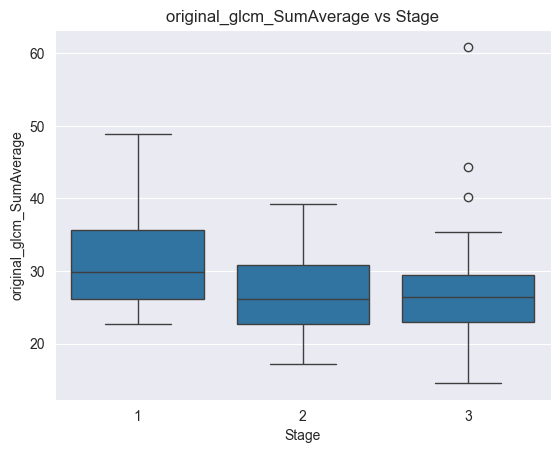

Kruskal-Wallis: original_glcm_SumEntropy -> H = 15.654, p = 0.0004 => Significant: True


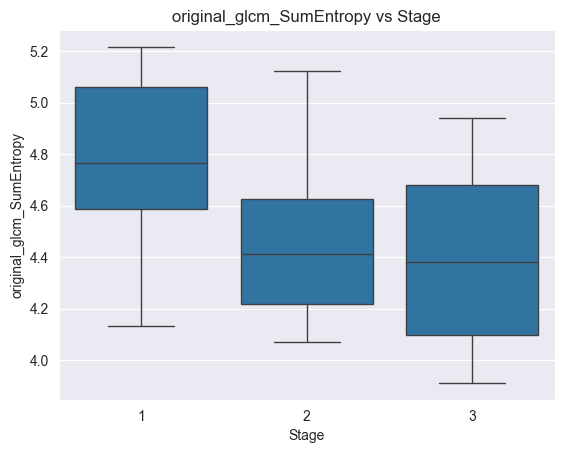

Kruskal-Wallis: original_glcm_SumSquares -> H = 15.456, p = 0.0004 => Significant: True


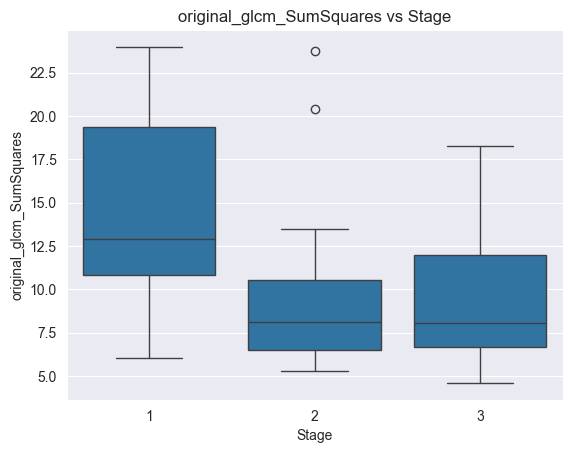

Kruskal-Wallis: original_glrlm_GrayLevelNonUniformity -> H = 2.551, p = 0.2793 => Significant: False


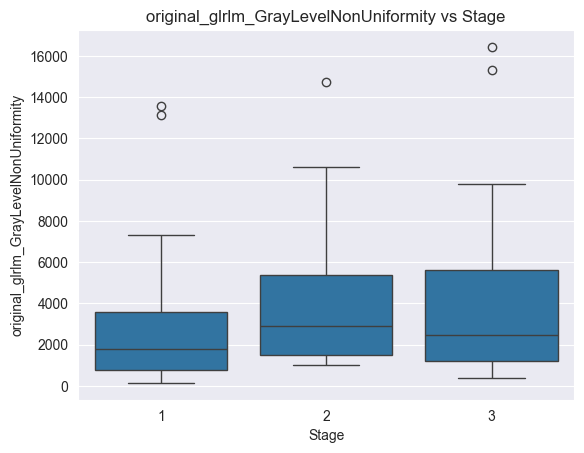

Kruskal-Wallis: original_glrlm_GrayLevelNonUniformityNormalized -> H = 17.443, p = 0.0002 => Significant: True


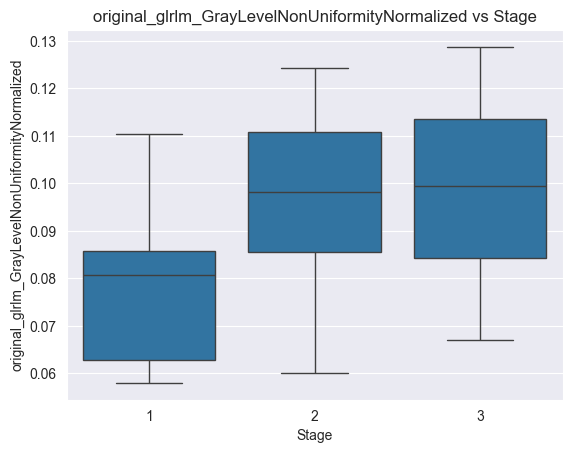

Kruskal-Wallis: original_glrlm_GrayLevelVariance -> H = 15.404, p = 0.0005 => Significant: True


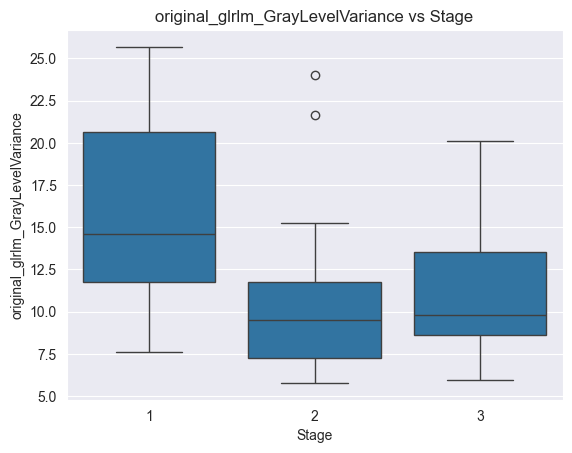

Kruskal-Wallis: original_glrlm_HighGrayLevelRunEmphasis -> H = 7.410, p = 0.0246 => Significant: True


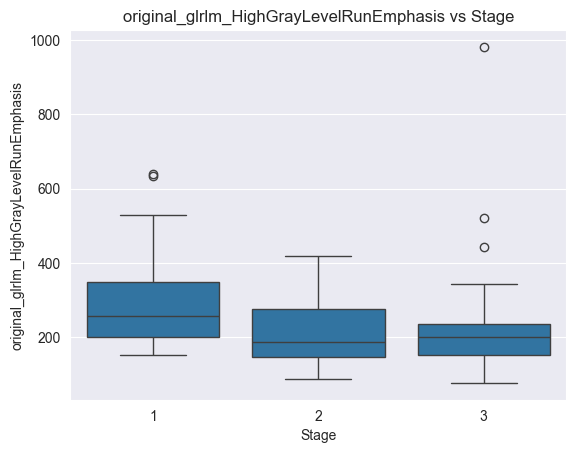

Kruskal-Wallis: original_glrlm_LongRunEmphasis -> H = 17.263, p = 0.0002 => Significant: True


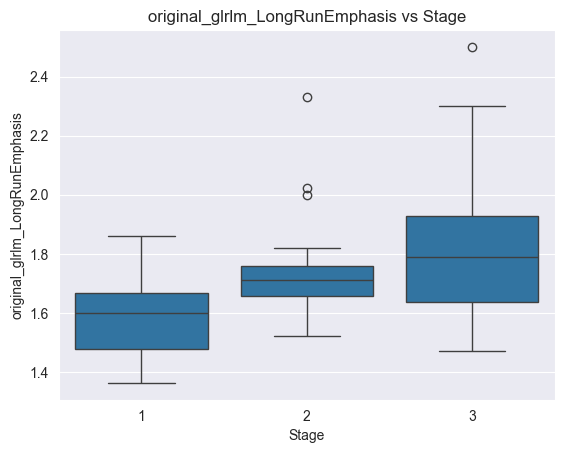

Kruskal-Wallis: original_glrlm_LongRunHighGrayLevelEmphasis -> H = 3.511, p = 0.1729 => Significant: False


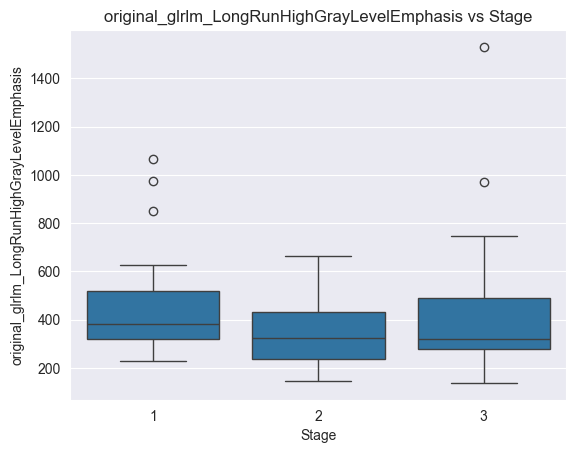

Kruskal-Wallis: original_glrlm_LongRunLowGrayLevelEmphasis -> H = 6.775, p = 0.0338 => Significant: True


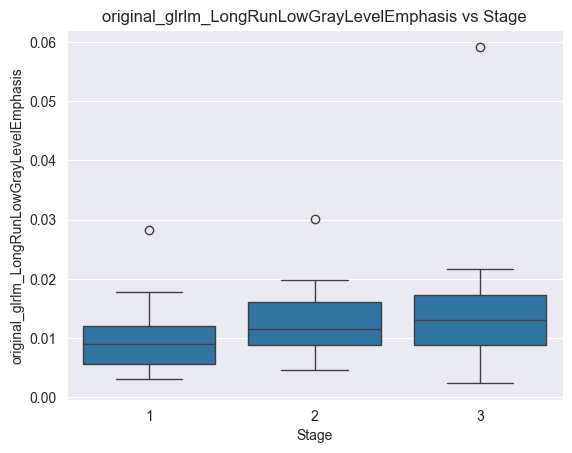

Kruskal-Wallis: original_glrlm_LowGrayLevelRunEmphasis -> H = 3.525, p = 0.1716 => Significant: False


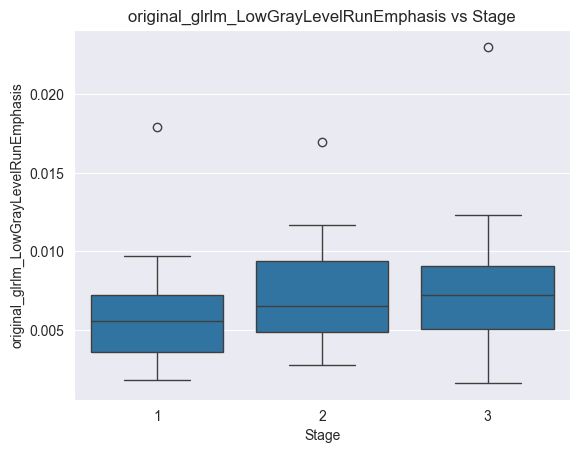

Kruskal-Wallis: original_glrlm_RunEntropy -> H = 12.135, p = 0.0023 => Significant: True


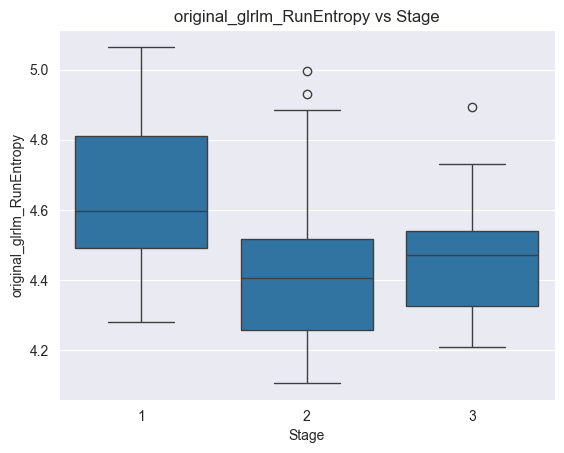

Kruskal-Wallis: original_glrlm_RunLengthNonUniformity -> H = 1.037, p = 0.5954 => Significant: False


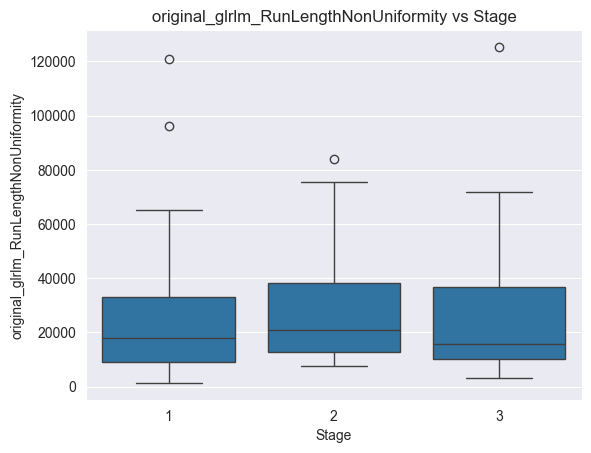

Kruskal-Wallis: original_glrlm_RunLengthNonUniformityNormalized -> H = 17.694, p = 0.0001 => Significant: True


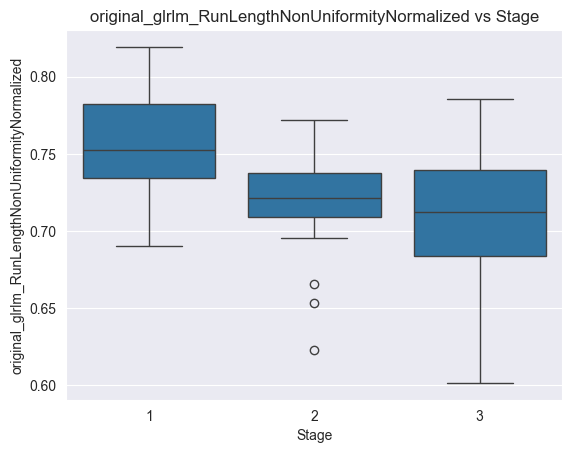

Kruskal-Wallis: original_glrlm_RunPercentage -> H = 17.351, p = 0.0002 => Significant: True


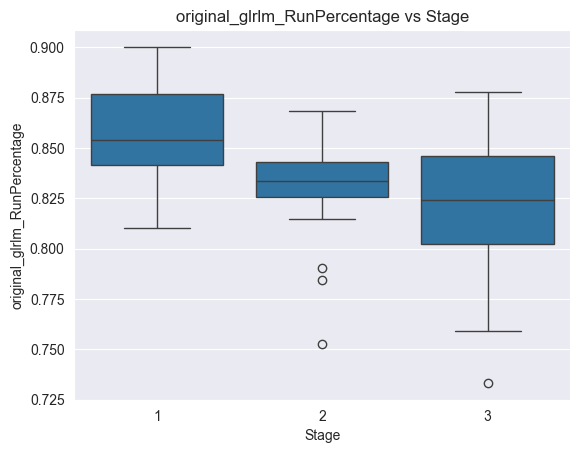

Kruskal-Wallis: original_glrlm_RunVariance -> H = 16.092, p = 0.0003 => Significant: True


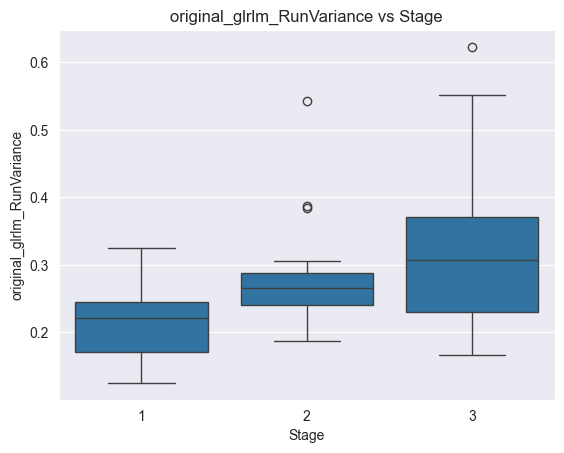

Kruskal-Wallis: original_glrlm_ShortRunEmphasis -> H = 17.811, p = 0.0001 => Significant: True


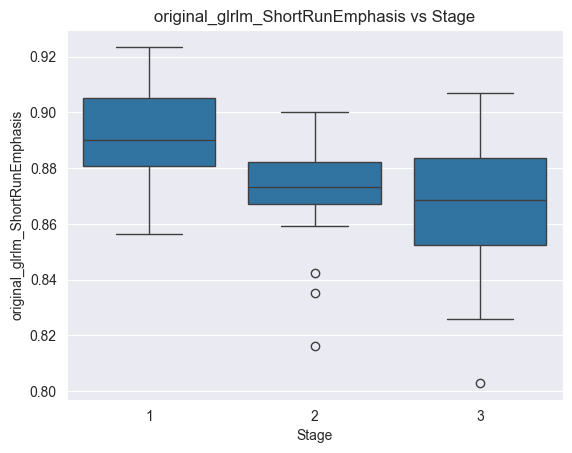

Kruskal-Wallis: original_glrlm_ShortRunHighGrayLevelEmphasis -> H = 8.611, p = 0.0135 => Significant: True


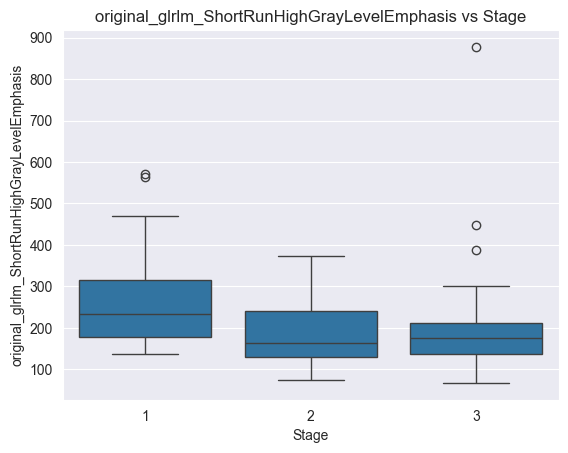

Kruskal-Wallis: original_glrlm_ShortRunLowGrayLevelEmphasis -> H = 3.114, p = 0.2108 => Significant: False


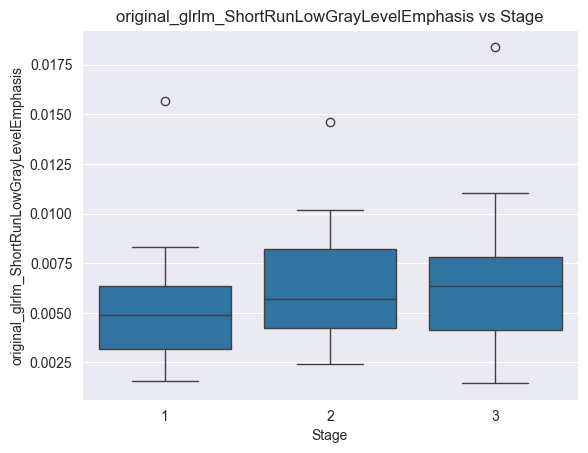

Kruskal-Wallis: original_glszm_GrayLevelNonUniformity -> H = 1.020, p = 0.6006 => Significant: False


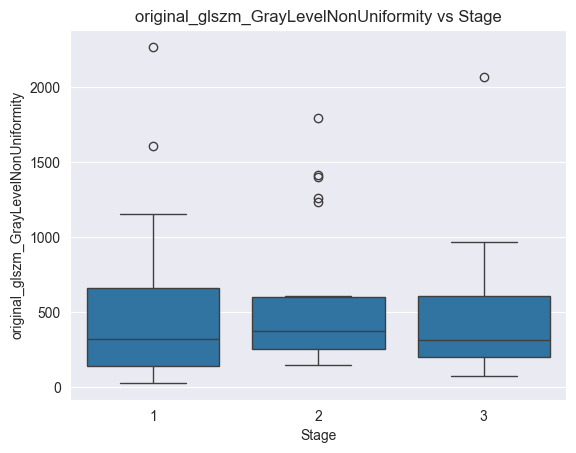

Kruskal-Wallis: original_glszm_GrayLevelNonUniformityNormalized -> H = 14.893, p = 0.0006 => Significant: True


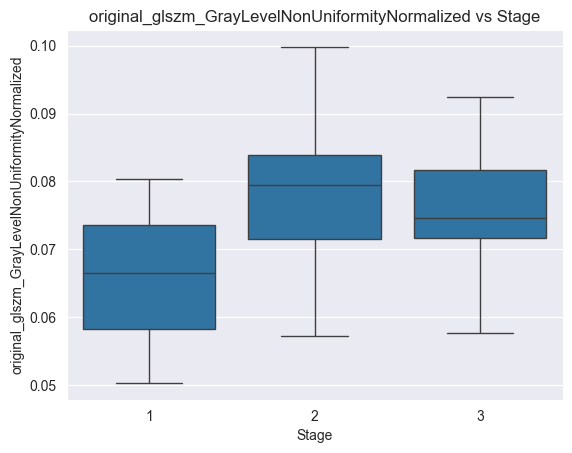

Kruskal-Wallis: original_glszm_GrayLevelVariance -> H = 14.214, p = 0.0008 => Significant: True


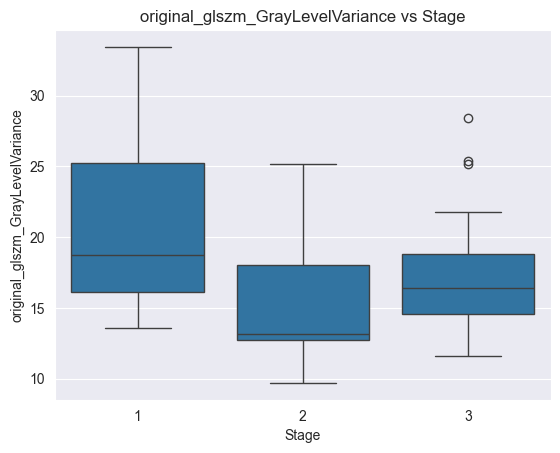

Kruskal-Wallis: original_glszm_HighGrayLevelZoneEmphasis -> H = 8.083, p = 0.0176 => Significant: True


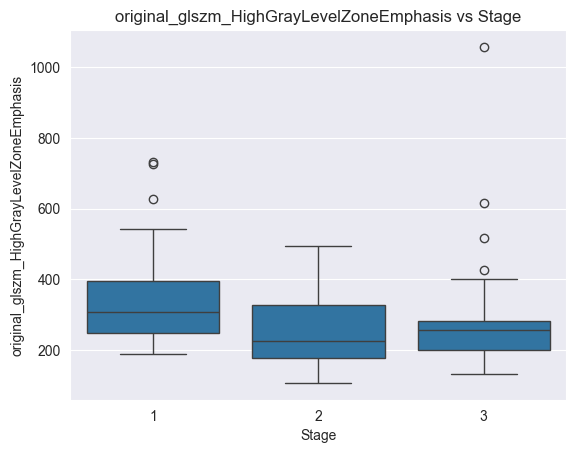

Kruskal-Wallis: original_glszm_LargeAreaEmphasis -> H = 6.165, p = 0.0459 => Significant: True


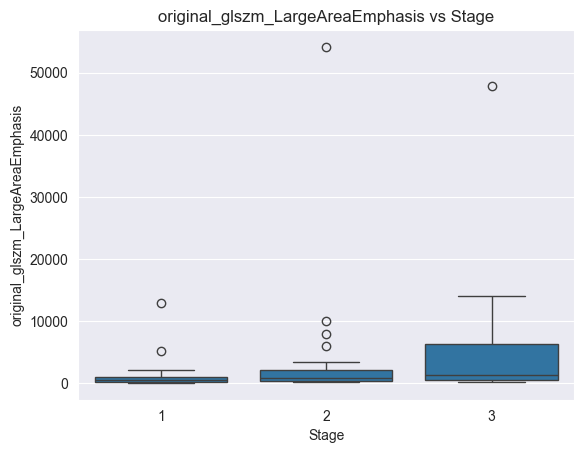

Kruskal-Wallis: original_glszm_LargeAreaHighGrayLevelEmphasis -> H = 3.686, p = 0.1584 => Significant: False


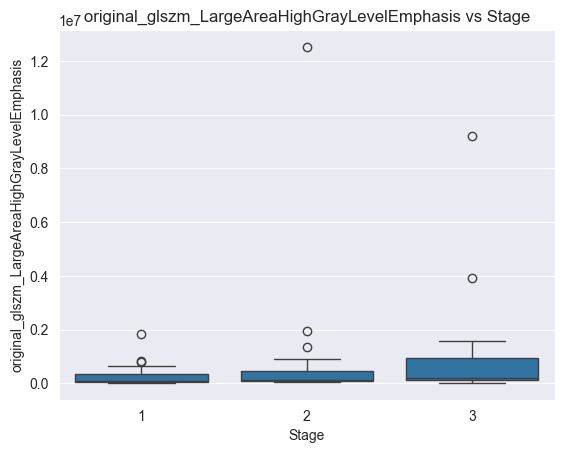

Kruskal-Wallis: original_glszm_LargeAreaLowGrayLevelEmphasis -> H = 9.205, p = 0.0100 => Significant: True


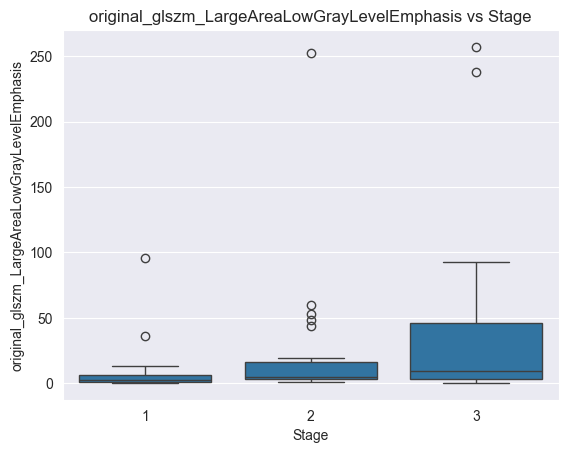

Kruskal-Wallis: original_glszm_LowGrayLevelZoneEmphasis -> H = 3.831, p = 0.1473 => Significant: False


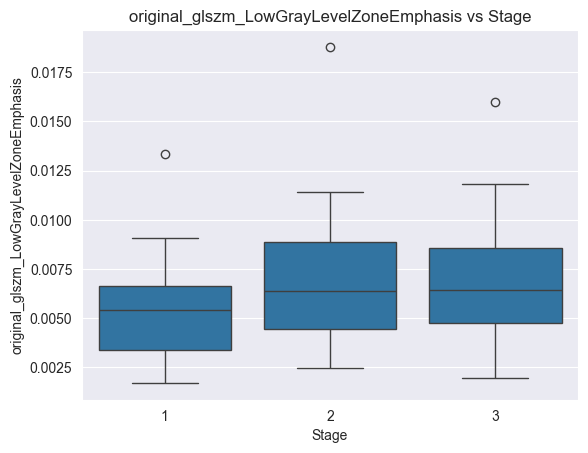

Kruskal-Wallis: original_glszm_SizeZoneNonUniformity -> H = 0.378, p = 0.8276 => Significant: False


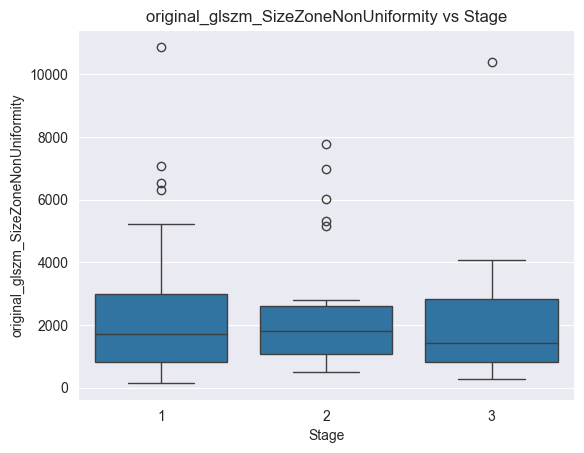

Kruskal-Wallis: original_glszm_SizeZoneNonUniformityNormalized -> H = 1.913, p = 0.3842 => Significant: False


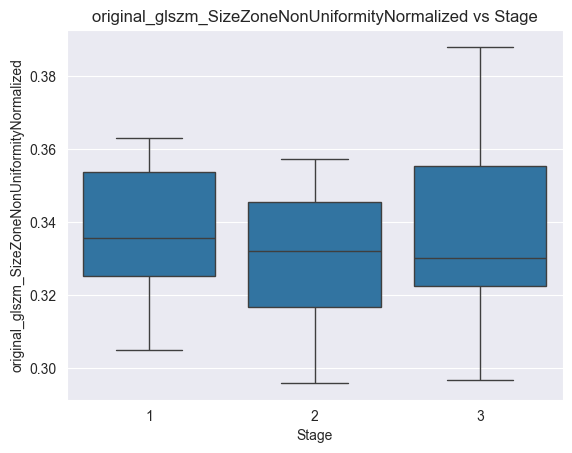

Kruskal-Wallis: original_glszm_SmallAreaEmphasis -> H = 1.932, p = 0.3806 => Significant: False


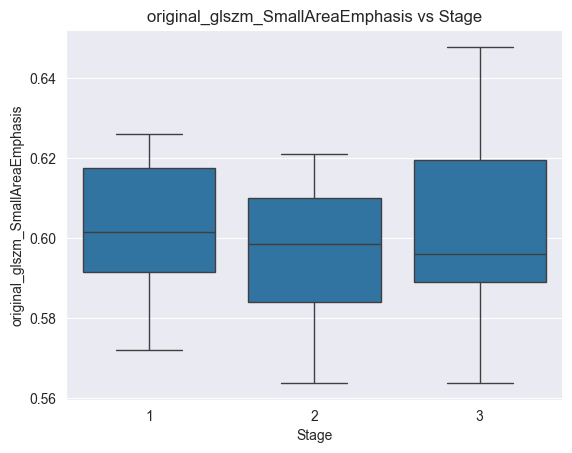

Kruskal-Wallis: original_glszm_SmallAreaHighGrayLevelEmphasis -> H = 8.082, p = 0.0176 => Significant: True


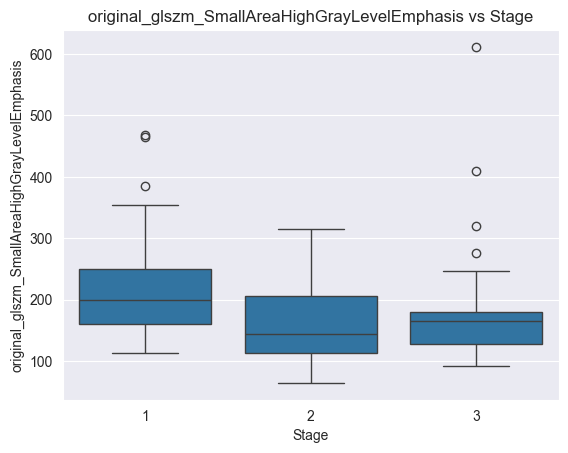

Kruskal-Wallis: original_glszm_SmallAreaLowGrayLevelEmphasis -> H = 3.827, p = 0.1476 => Significant: False


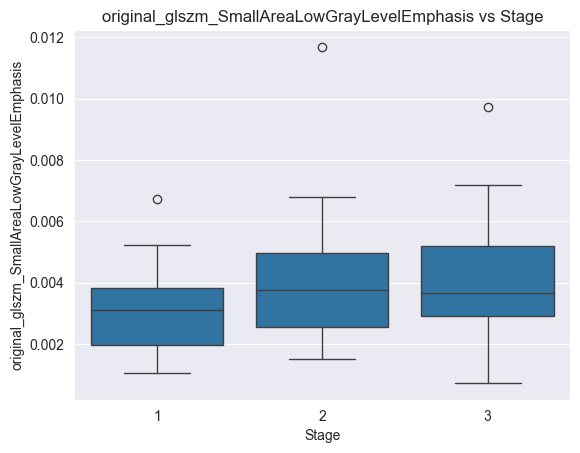

Kruskal-Wallis: original_glszm_ZoneEntropy -> H = 9.204, p = 0.0100 => Significant: True


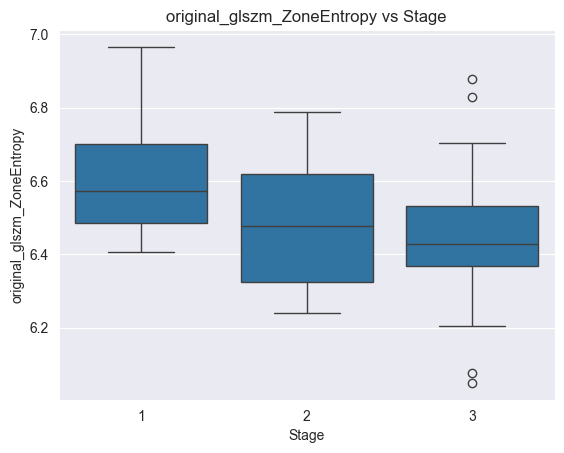

Kruskal-Wallis: original_glszm_ZonePercentage -> H = 13.006, p = 0.0015 => Significant: True


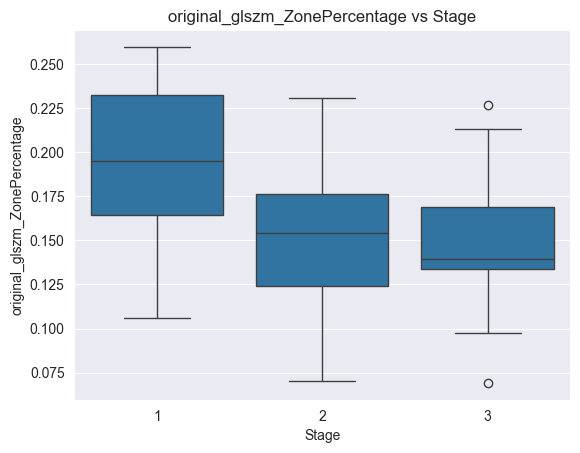

Kruskal-Wallis: original_glszm_ZoneVariance -> H = 6.165, p = 0.0459 => Significant: True


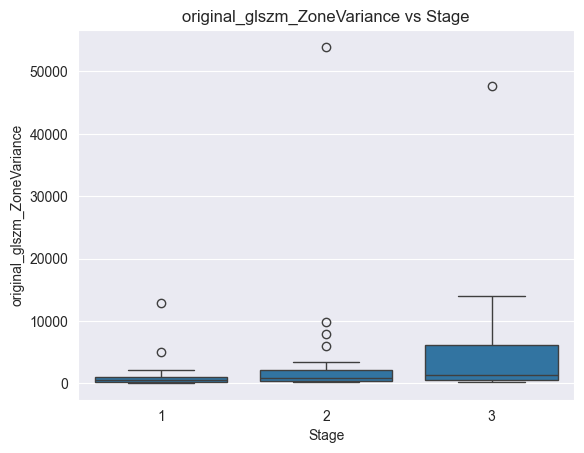

Kruskal-Wallis: original_gldm_DependenceEntropy -> H = 4.738, p = 0.0936 => Significant: False


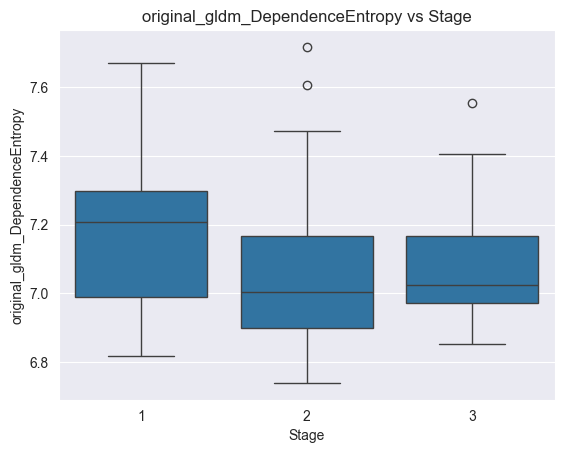

Kruskal-Wallis: original_gldm_DependenceNonUniformity -> H = 1.038, p = 0.5950 => Significant: False


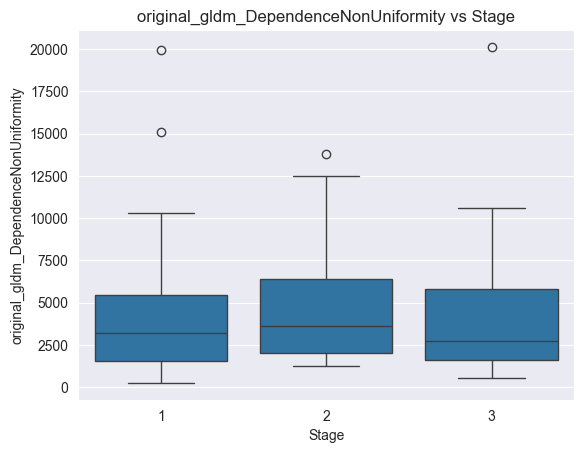

Kruskal-Wallis: original_gldm_DependenceNonUniformityNormalized -> H = 15.908, p = 0.0004 => Significant: True


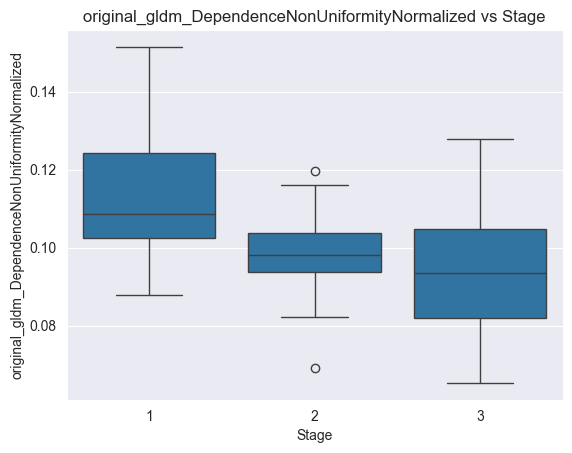

Kruskal-Wallis: original_gldm_DependenceVariance -> H = 12.515, p = 0.0019 => Significant: True


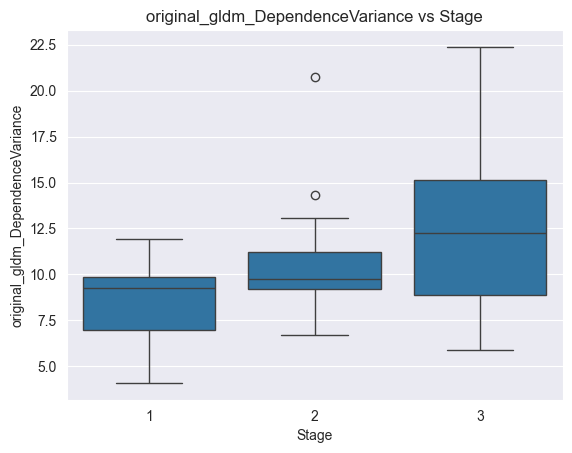

Kruskal-Wallis: original_gldm_GrayLevelNonUniformity -> H = 3.194, p = 0.2025 => Significant: False


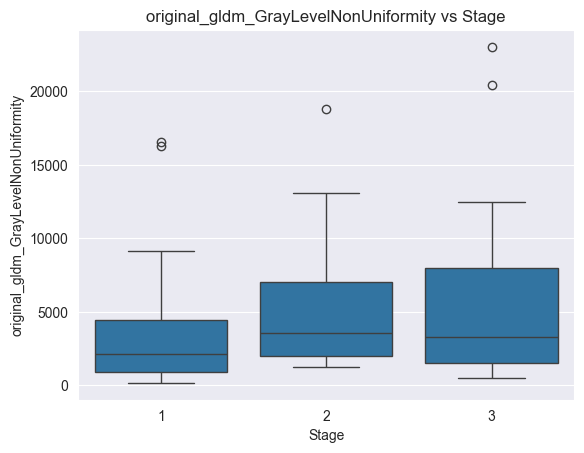

Kruskal-Wallis: original_gldm_GrayLevelVariance -> H = 15.474, p = 0.0004 => Significant: True


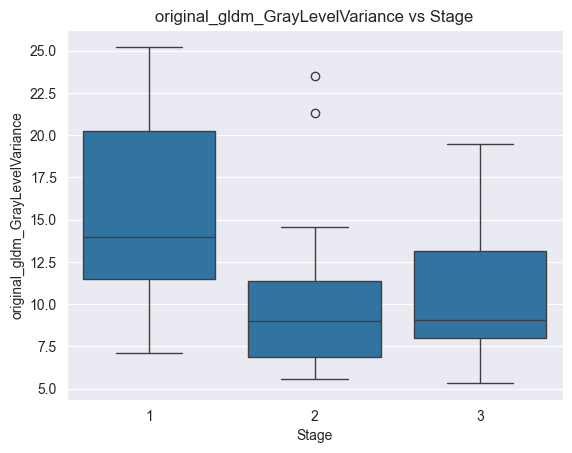

Kruskal-Wallis: original_gldm_HighGrayLevelEmphasis -> H = 7.532, p = 0.0231 => Significant: True


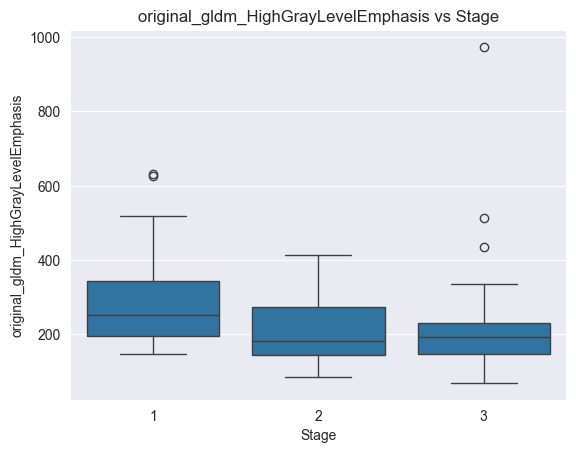

Kruskal-Wallis: original_gldm_LargeDependenceEmphasis -> H = 17.116, p = 0.0002 => Significant: True


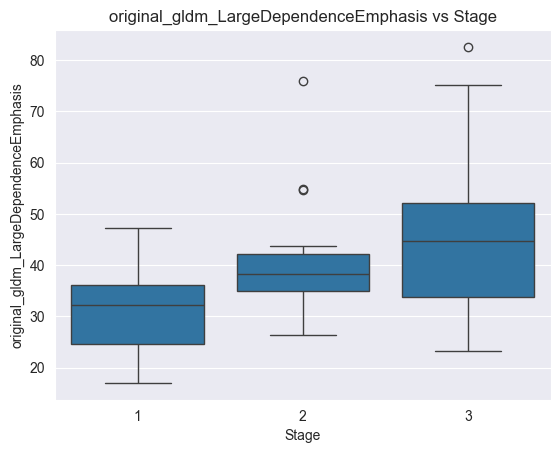

Kruskal-Wallis: original_gldm_LargeDependenceHighGrayLevelEmphasis -> H = 0.276, p = 0.8710 => Significant: False


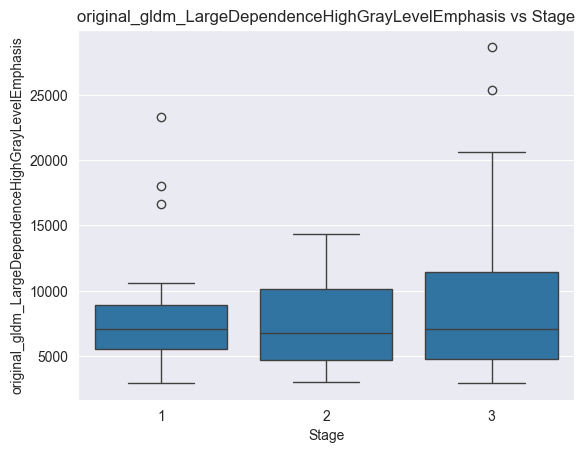

Kruskal-Wallis: original_gldm_LargeDependenceLowGrayLevelEmphasis -> H = 9.814, p = 0.0074 => Significant: True


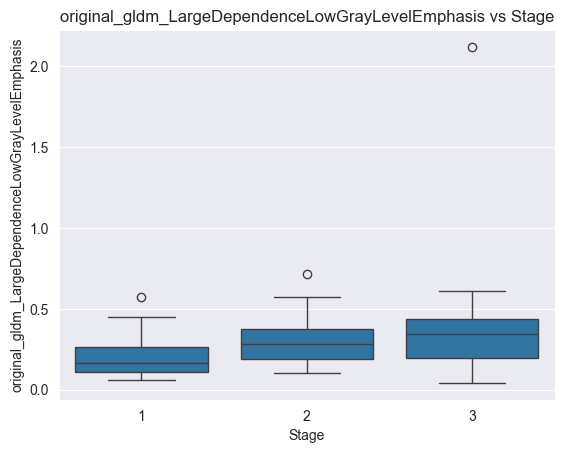

Kruskal-Wallis: original_gldm_LowGrayLevelEmphasis -> H = 3.477, p = 0.1757 => Significant: False


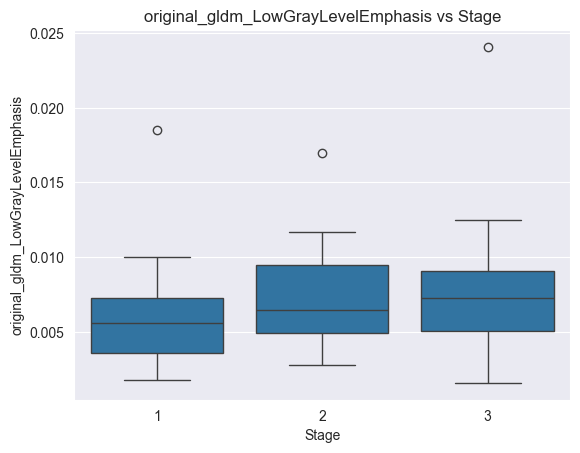

Kruskal-Wallis: original_gldm_SmallDependenceEmphasis -> H = 14.060, p = 0.0009 => Significant: True


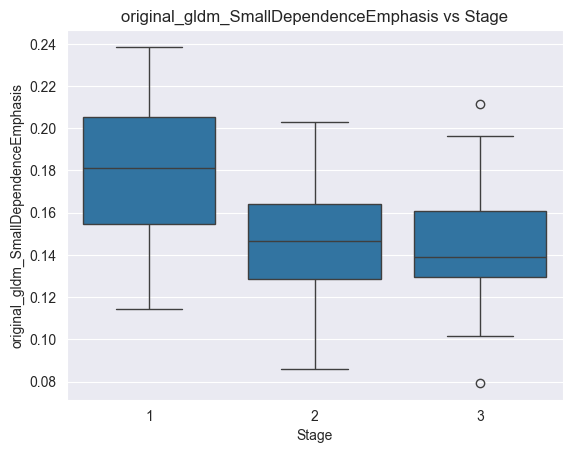

Kruskal-Wallis: original_gldm_SmallDependenceHighGrayLevelEmphasis -> H = 12.939, p = 0.0016 => Significant: True


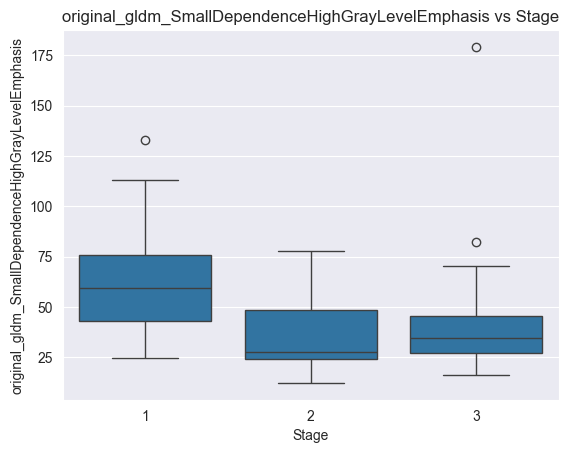

Kruskal-Wallis: original_gldm_SmallDependenceLowGrayLevelEmphasis -> H = 0.438, p = 0.8034 => Significant: False


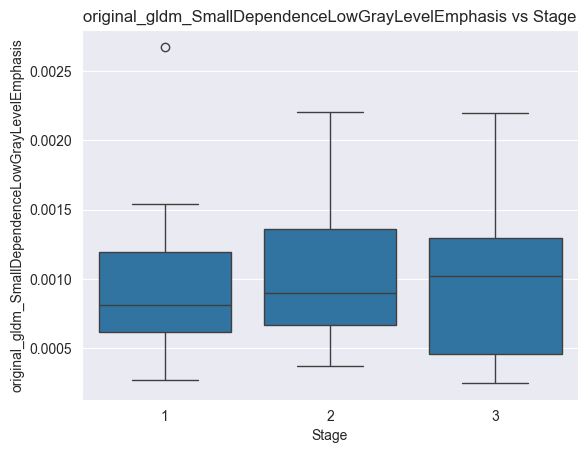

Kruskal-Wallis: original_ngtdm_Busyness -> H = 6.642, p = 0.0361 => Significant: True


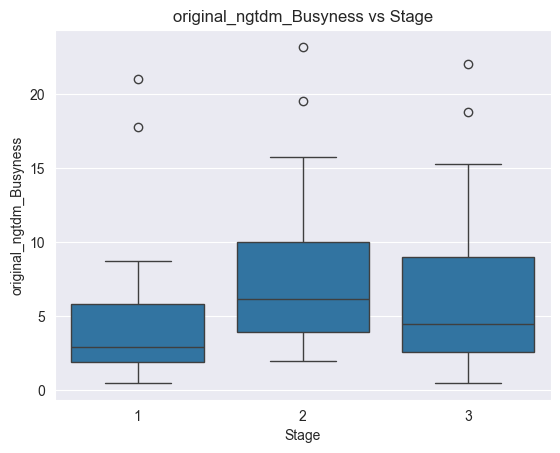

Kruskal-Wallis: original_ngtdm_Coarseness -> H = 1.354, p = 0.5082 => Significant: False


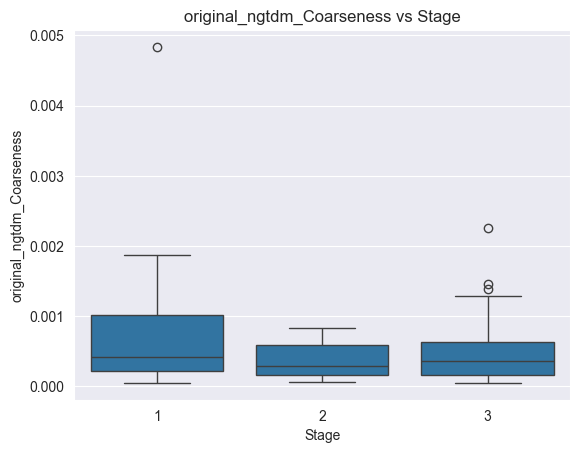

Kruskal-Wallis: original_ngtdm_Complexity -> H = 11.092, p = 0.0039 => Significant: True


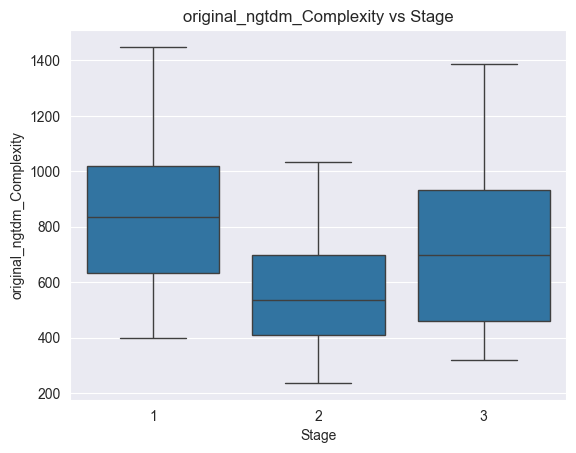

Kruskal-Wallis: original_ngtdm_Contrast -> H = 9.240, p = 0.0099 => Significant: True


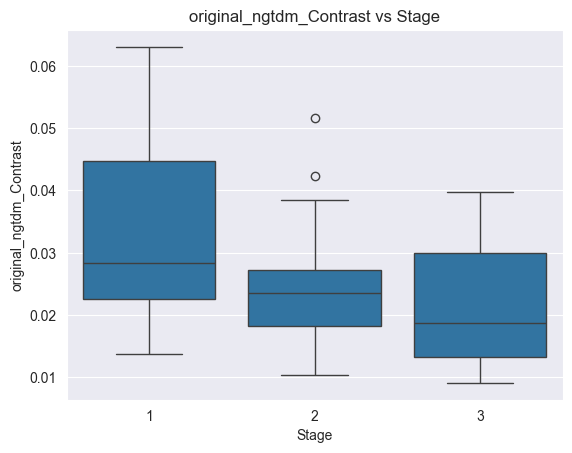

Kruskal-Wallis: original_ngtdm_Strength -> H = 6.278, p = 0.0433 => Significant: True


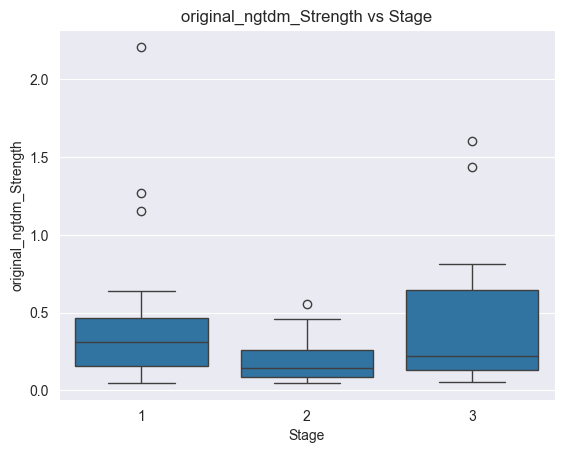

Kruskal-Wallis: gradient_firstorder_10Percentile -> H = 18.631, p = 0.0001 => Significant: True


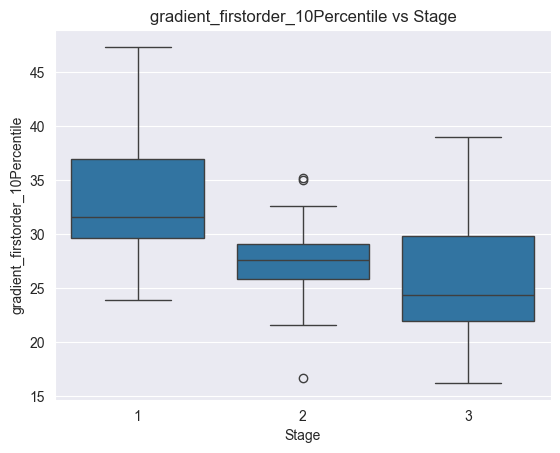

Kruskal-Wallis: gradient_firstorder_90Percentile -> H = 13.227, p = 0.0013 => Significant: True


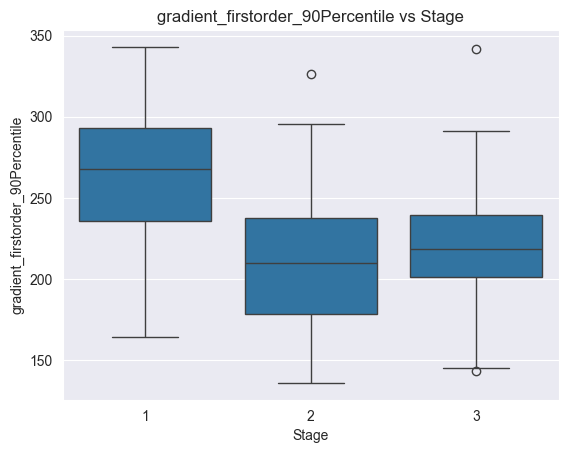

Kruskal-Wallis: gradient_firstorder_Energy -> H = 0.294, p = 0.8632 => Significant: False


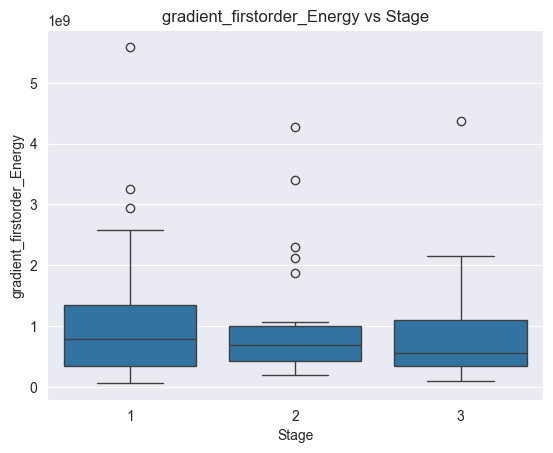

Kruskal-Wallis: gradient_firstorder_Entropy -> H = 14.864, p = 0.0006 => Significant: True


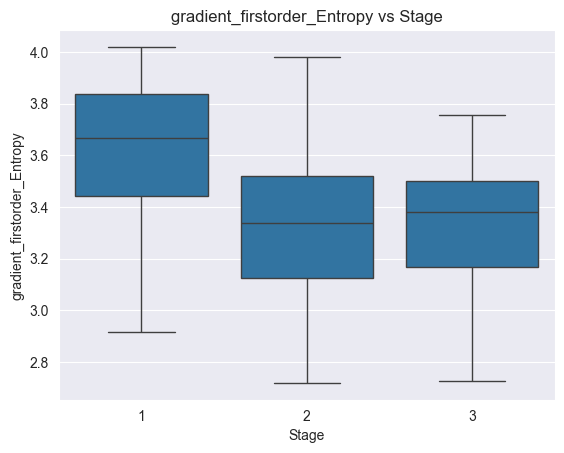

Kruskal-Wallis: gradient_firstorder_InterquartileRange -> H = 12.851, p = 0.0016 => Significant: True


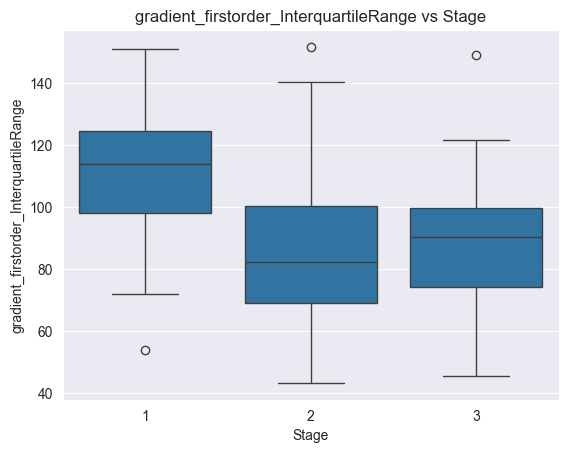

Kruskal-Wallis: gradient_firstorder_Kurtosis -> H = 4.872, p = 0.0875 => Significant: False


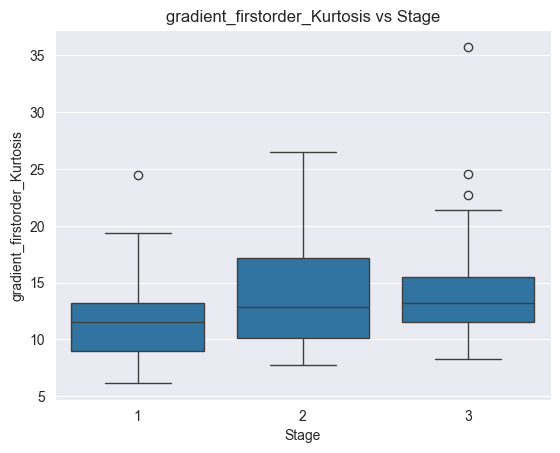

Kruskal-Wallis: gradient_firstorder_Maximum -> H = 3.555, p = 0.1691 => Significant: False


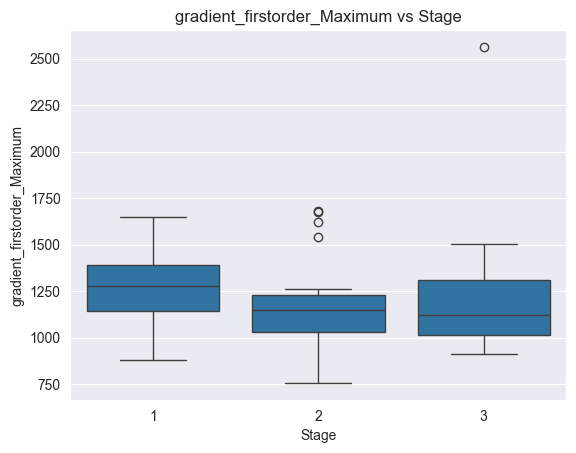

Kruskal-Wallis: gradient_firstorder_MeanAbsoluteDeviation -> H = 12.315, p = 0.0021 => Significant: True


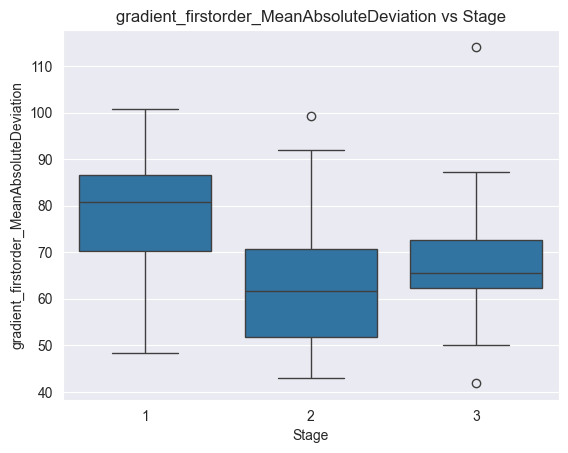

Kruskal-Wallis: gradient_firstorder_Mean -> H = 15.965, p = 0.0003 => Significant: True


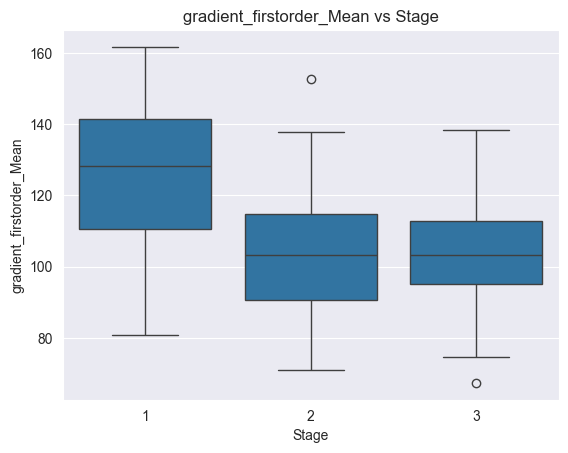

Kruskal-Wallis: gradient_firstorder_Median -> H = 16.229, p = 0.0003 => Significant: True


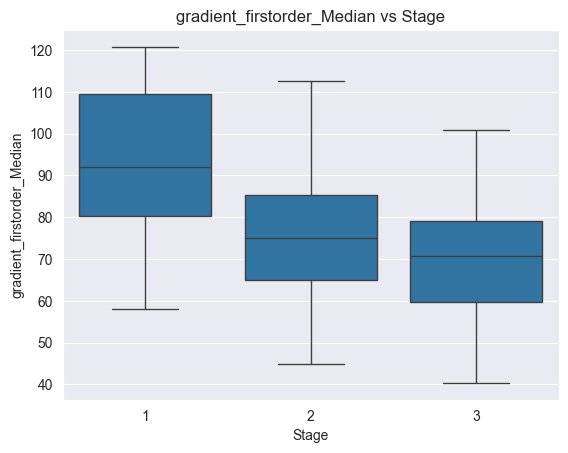

Kruskal-Wallis: gradient_firstorder_Minimum -> H = 1.500, p = 0.4723 => Significant: False


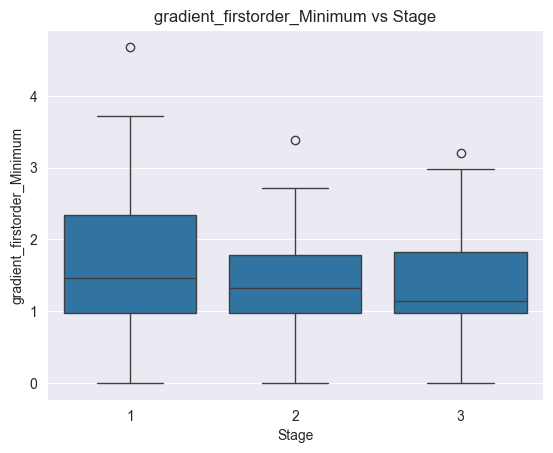

Kruskal-Wallis: gradient_firstorder_Range -> H = 3.505, p = 0.1733 => Significant: False


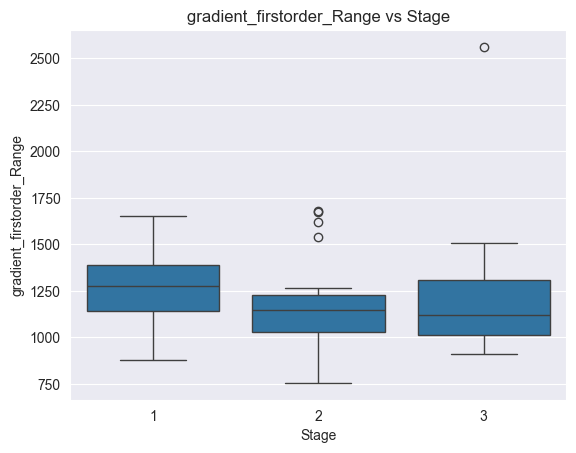

Kruskal-Wallis: gradient_firstorder_RobustMeanAbsoluteDeviation -> H = 12.642, p = 0.0018 => Significant: True


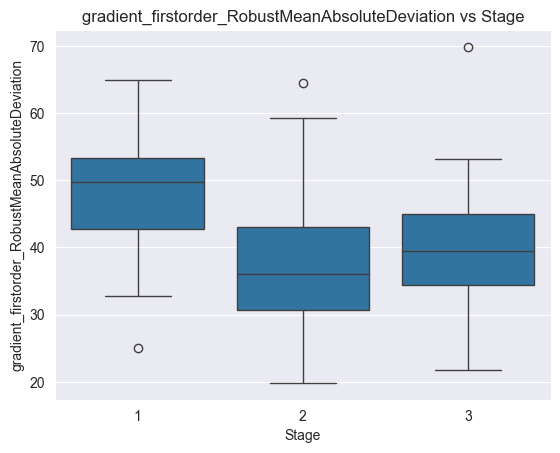

Kruskal-Wallis: gradient_firstorder_RootMeanSquared -> H = 14.307, p = 0.0008 => Significant: True


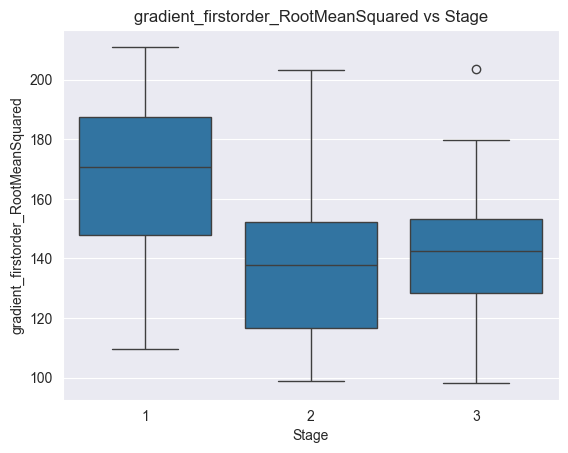

Kruskal-Wallis: gradient_firstorder_Skewness -> H = 6.080, p = 0.0478 => Significant: True


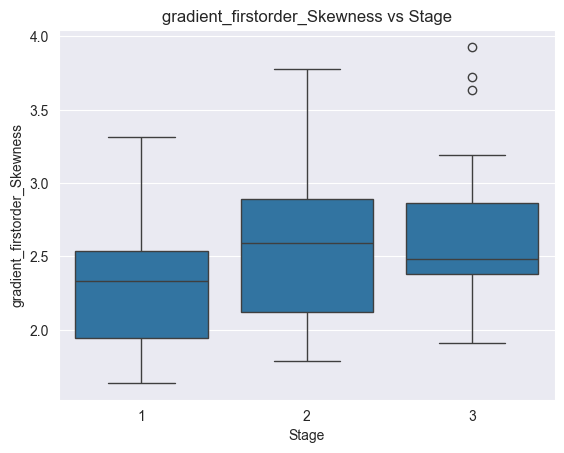

Kruskal-Wallis: gradient_firstorder_TotalEnergy -> H = 0.255, p = 0.8803 => Significant: False


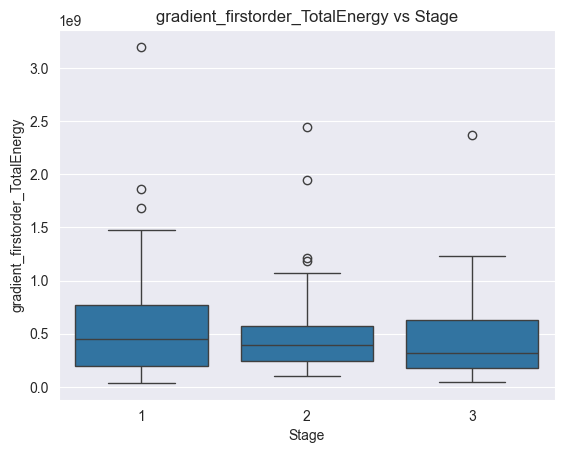

Kruskal-Wallis: gradient_firstorder_Uniformity -> H = 15.224, p = 0.0005 => Significant: True


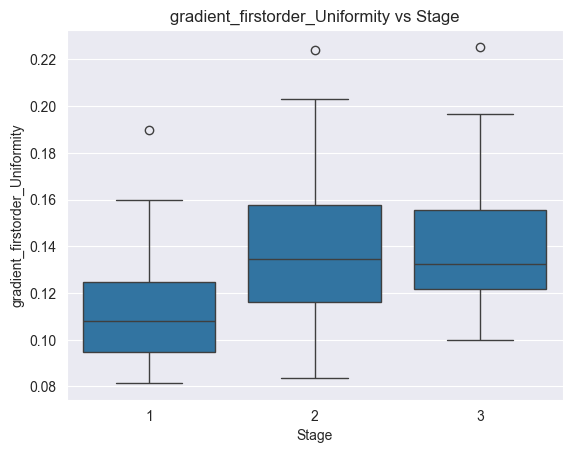

Kruskal-Wallis: gradient_firstorder_Variance -> H = 12.515, p = 0.0019 => Significant: True


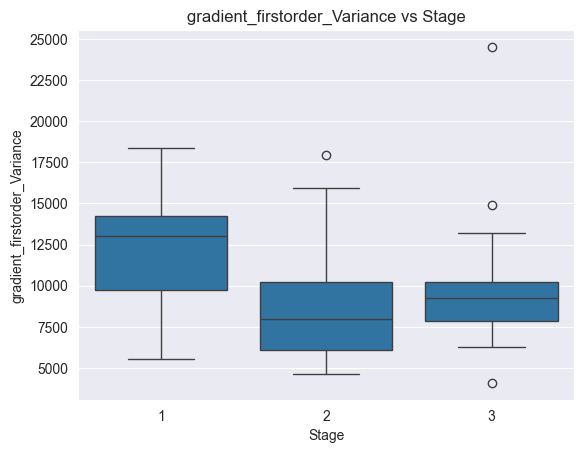

Kruskal-Wallis: gradient_glcm_Autocorrelation -> H = 15.758, p = 0.0004 => Significant: True


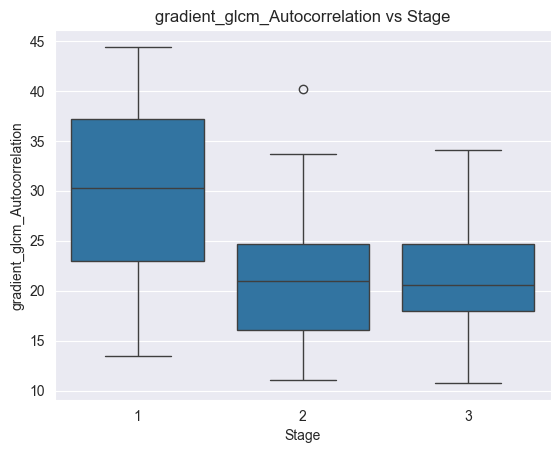

Kruskal-Wallis: gradient_glcm_ClusterProminence -> H = 10.008, p = 0.0067 => Significant: True


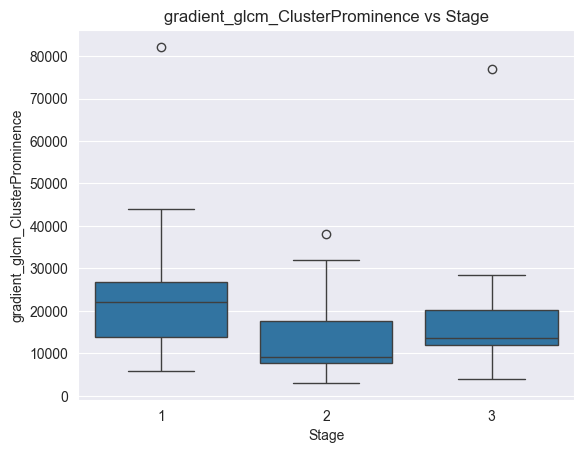

Kruskal-Wallis: gradient_glcm_ClusterShade -> H = 11.060, p = 0.0040 => Significant: True


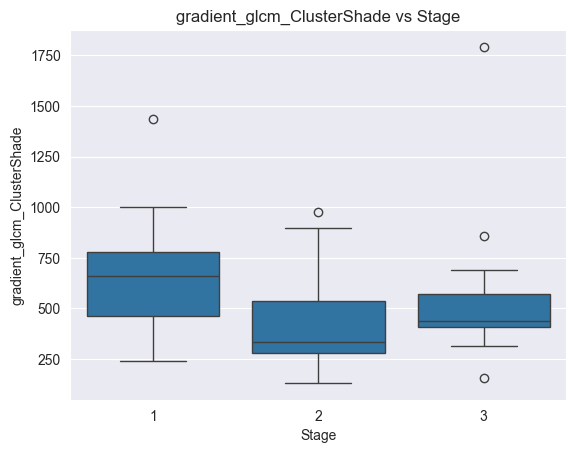

Kruskal-Wallis: gradient_glcm_ClusterTendency -> H = 13.088, p = 0.0014 => Significant: True


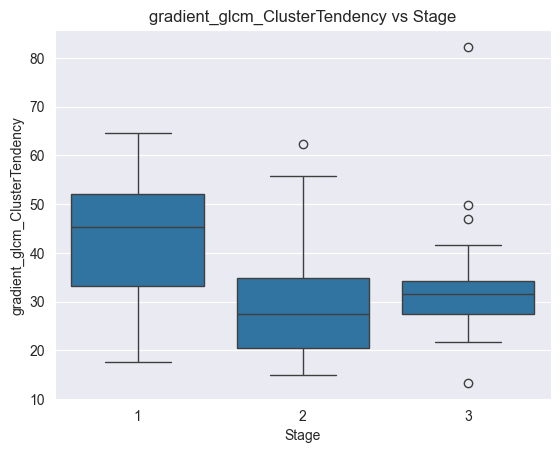

Kruskal-Wallis: gradient_glcm_Contrast -> H = 11.475, p = 0.0032 => Significant: True


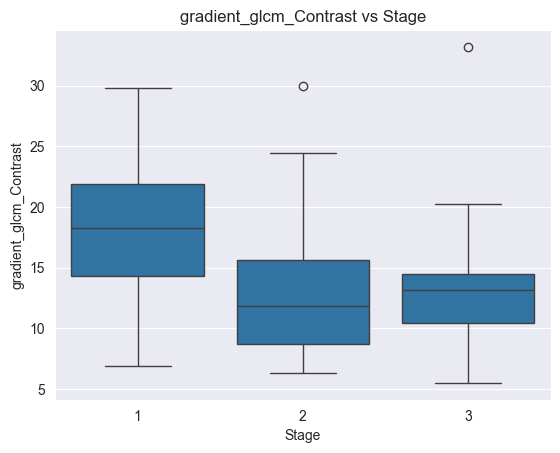

Kruskal-Wallis: gradient_glcm_Correlation -> H = 6.072, p = 0.0480 => Significant: True


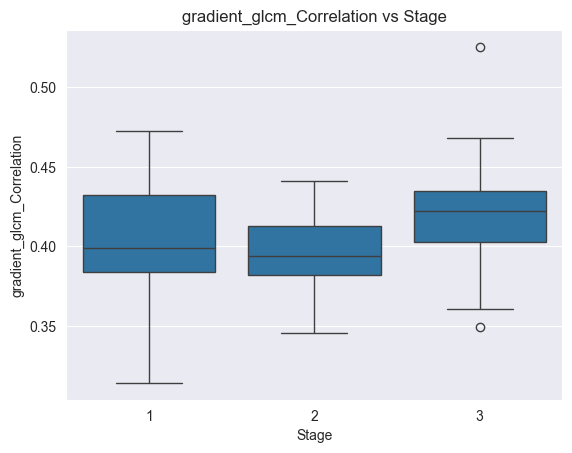

Kruskal-Wallis: gradient_glcm_DifferenceAverage -> H = 13.272, p = 0.0013 => Significant: True


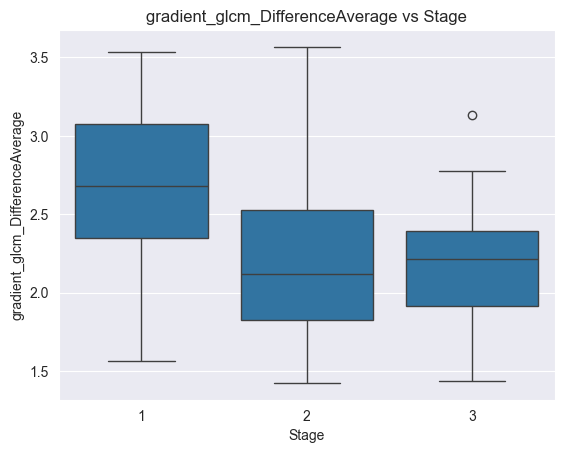

Kruskal-Wallis: gradient_glcm_DifferenceEntropy -> H = 13.442, p = 0.0012 => Significant: True


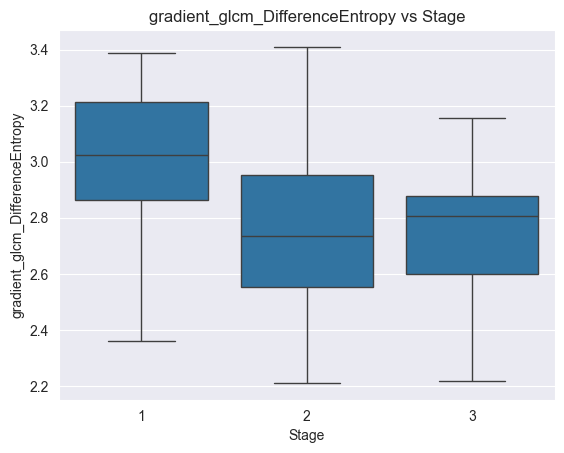

Kruskal-Wallis: gradient_glcm_DifferenceVariance -> H = 11.078, p = 0.0039 => Significant: True


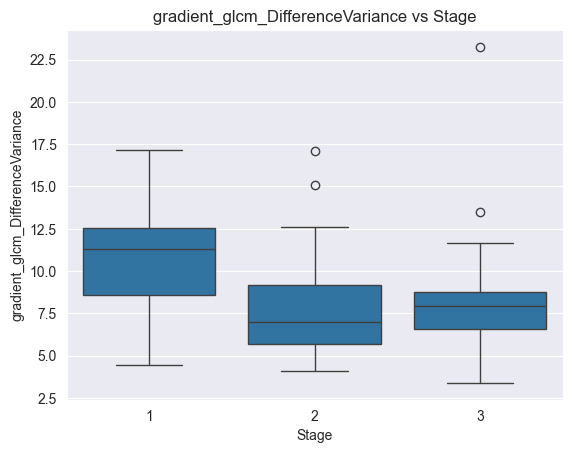

Kruskal-Wallis: gradient_glcm_Id -> H = 15.773, p = 0.0004 => Significant: True


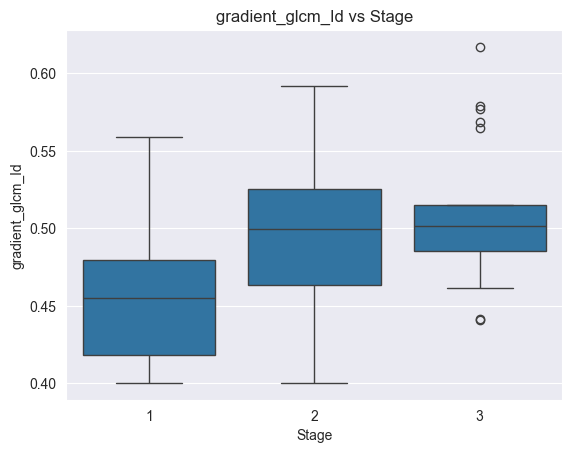

Kruskal-Wallis: gradient_glcm_Idm -> H = 15.885, p = 0.0004 => Significant: True


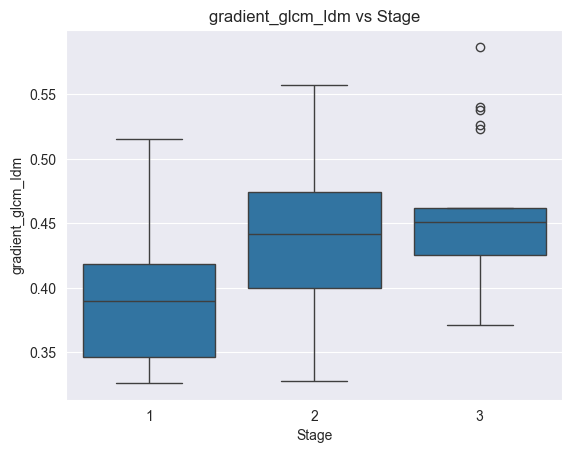

Kruskal-Wallis: gradient_glcm_Idmn -> H = 1.658, p = 0.4365 => Significant: False


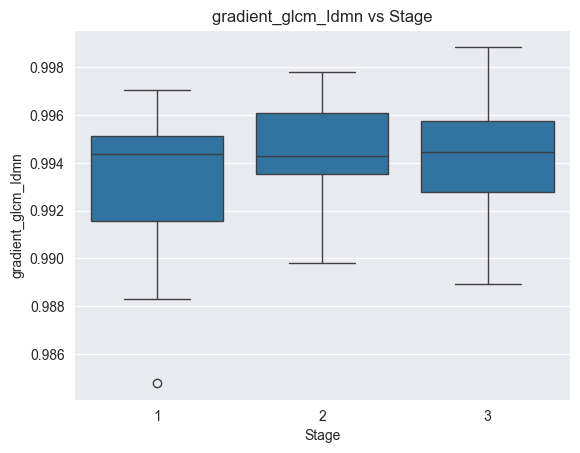

Kruskal-Wallis: gradient_glcm_Idn -> H = 2.571, p = 0.2766 => Significant: False


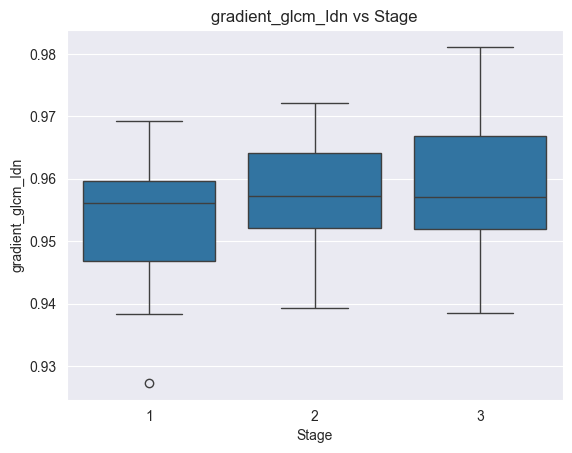

Kruskal-Wallis: gradient_glcm_Imc1 -> H = 12.520, p = 0.0019 => Significant: True


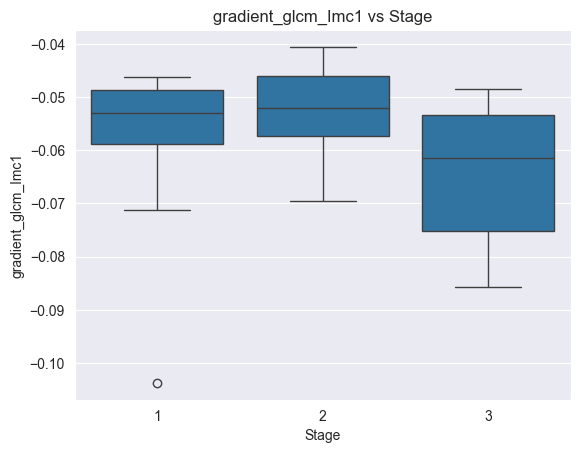

Kruskal-Wallis: gradient_glcm_Imc2 -> H = 13.748, p = 0.0010 => Significant: True


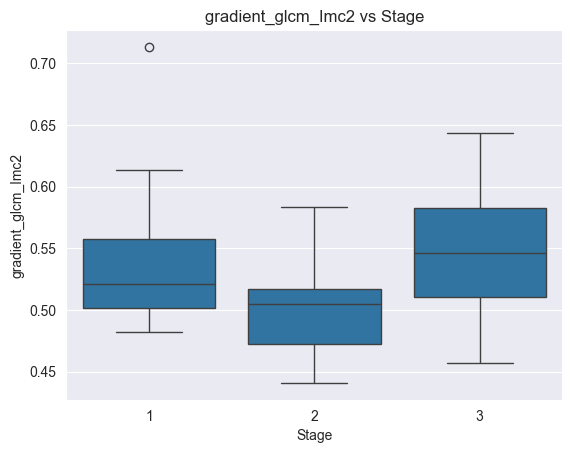

Kruskal-Wallis: gradient_glcm_InverseVariance -> H = 11.571, p = 0.0031 => Significant: True


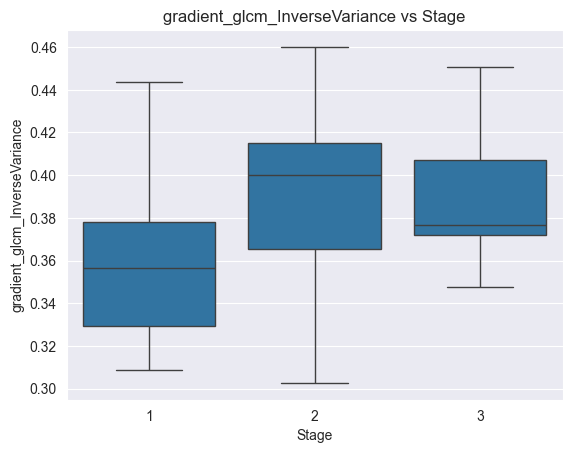

Kruskal-Wallis: gradient_glcm_JointAverage -> H = 16.963, p = 0.0002 => Significant: True


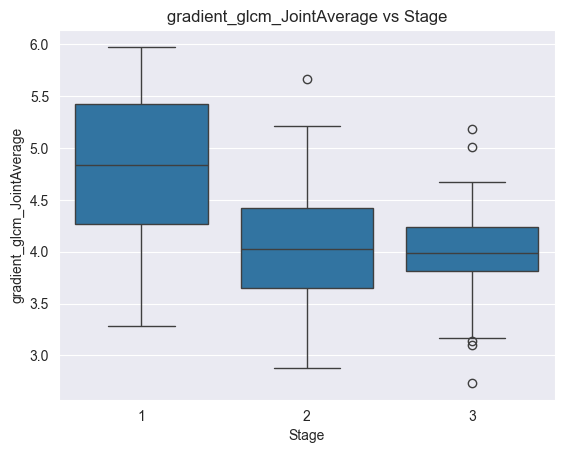

Kruskal-Wallis: gradient_glcm_JointEnergy -> H = 15.432, p = 0.0004 => Significant: True


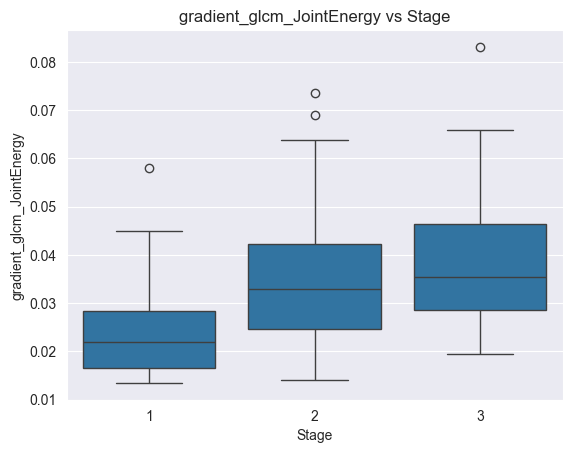

Kruskal-Wallis: gradient_glcm_JointEntropy -> H = 15.341, p = 0.0005 => Significant: True


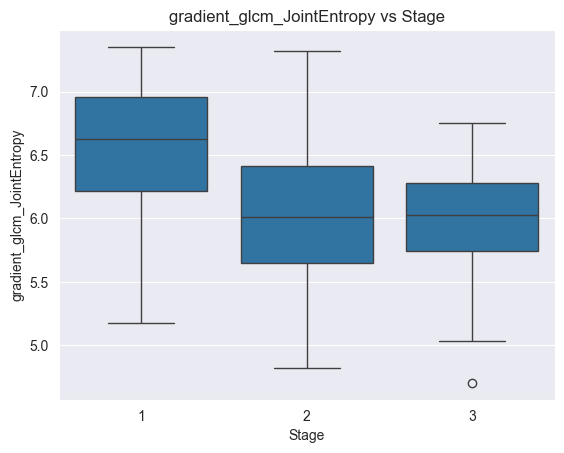

Kruskal-Wallis: gradient_glcm_MCC -> H = 1.864, p = 0.3937 => Significant: False


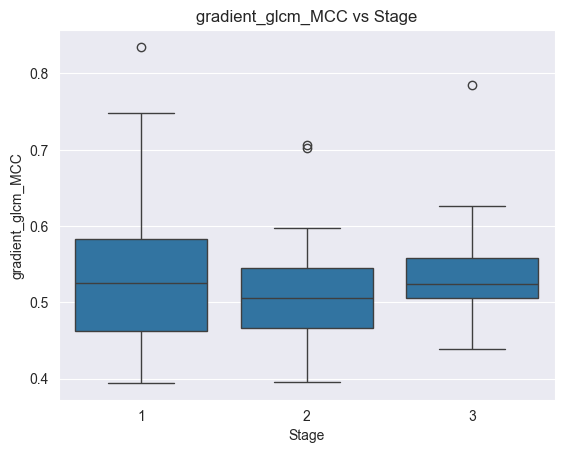

Kruskal-Wallis: gradient_glcm_MaximumProbability -> H = 13.665, p = 0.0011 => Significant: True


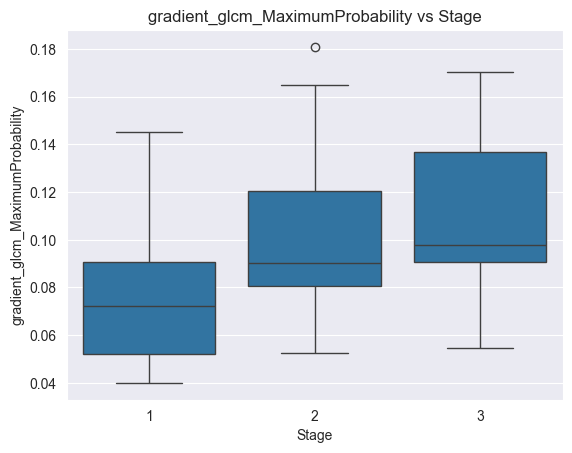

Kruskal-Wallis: gradient_glcm_SumAverage -> H = 16.963, p = 0.0002 => Significant: True


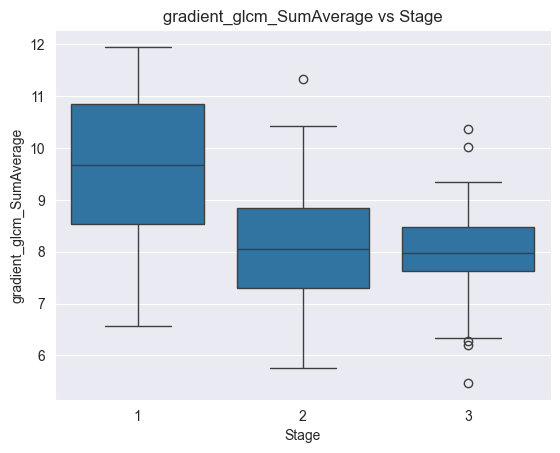

Kruskal-Wallis: gradient_glcm_SumEntropy -> H = 14.978, p = 0.0006 => Significant: True


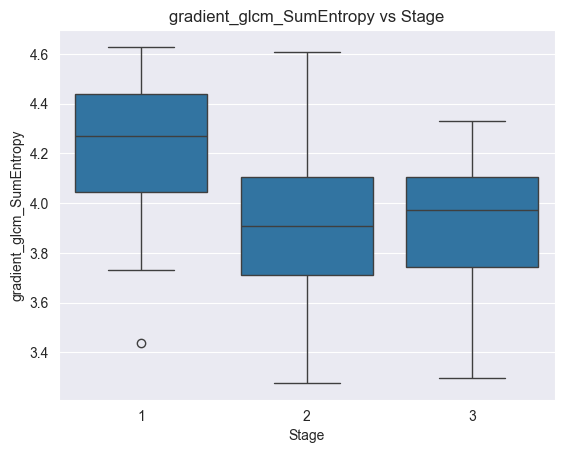

Kruskal-Wallis: gradient_glcm_SumSquares -> H = 12.393, p = 0.0020 => Significant: True


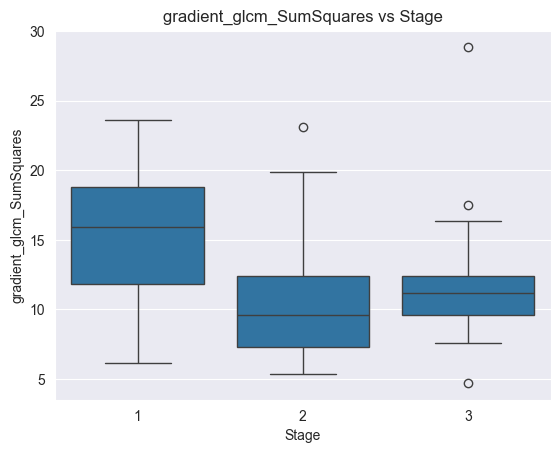

Kruskal-Wallis: gradient_glrlm_GrayLevelNonUniformity -> H = 2.782, p = 0.2488 => Significant: False


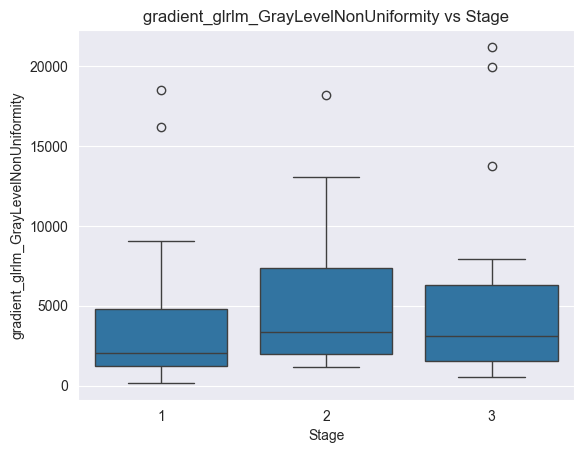

Kruskal-Wallis: gradient_glrlm_GrayLevelNonUniformityNormalized -> H = 14.776, p = 0.0006 => Significant: True


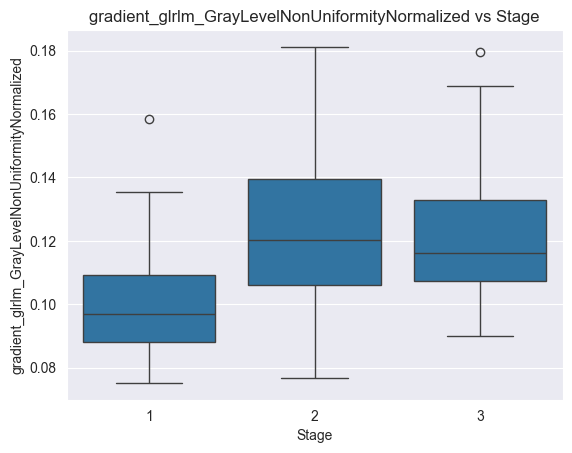

Kruskal-Wallis: gradient_glrlm_GrayLevelVariance -> H = 11.818, p = 0.0027 => Significant: True


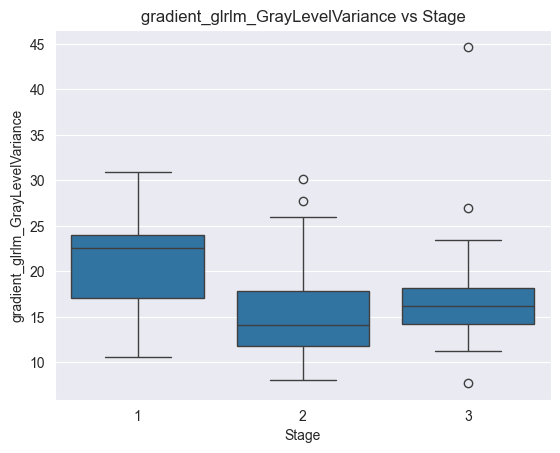

Kruskal-Wallis: gradient_glrlm_HighGrayLevelRunEmphasis -> H = 13.656, p = 0.0011 => Significant: True


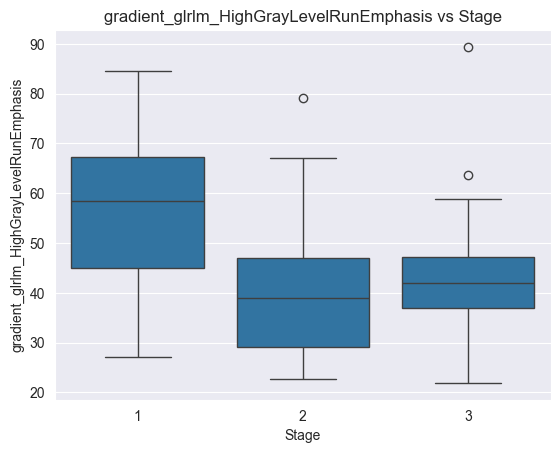

Kruskal-Wallis: gradient_glrlm_LongRunEmphasis -> H = 12.170, p = 0.0023 => Significant: True


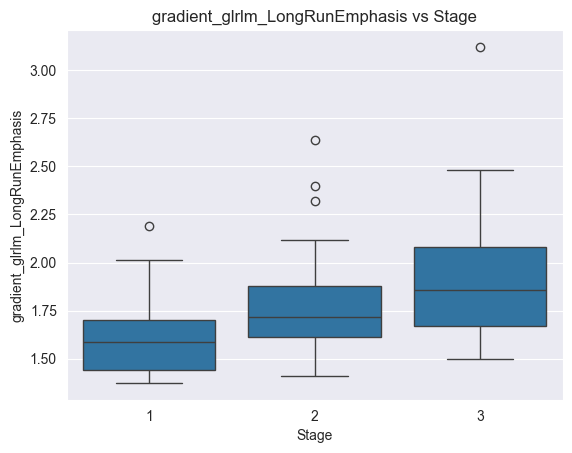

Kruskal-Wallis: gradient_glrlm_LongRunHighGrayLevelEmphasis -> H = 14.463, p = 0.0007 => Significant: True


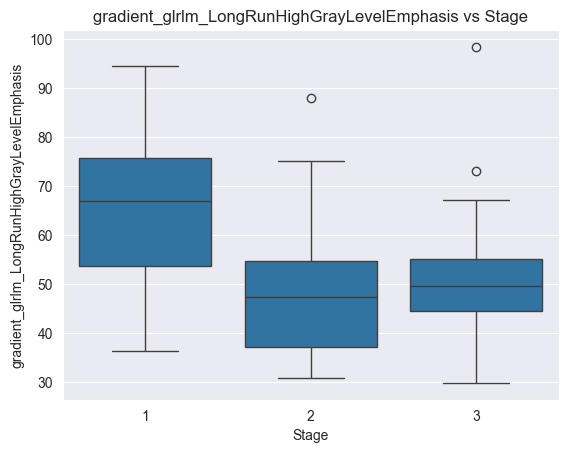

Kruskal-Wallis: gradient_glrlm_LongRunLowGrayLevelEmphasis -> H = 17.708, p = 0.0001 => Significant: True


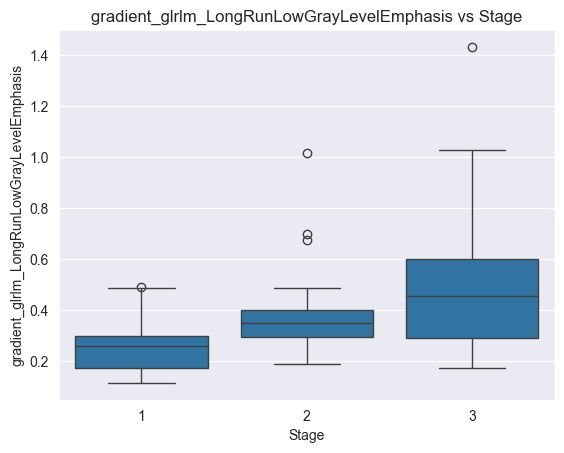

Kruskal-Wallis: gradient_glrlm_LowGrayLevelRunEmphasis -> H = 18.558, p = 0.0001 => Significant: True


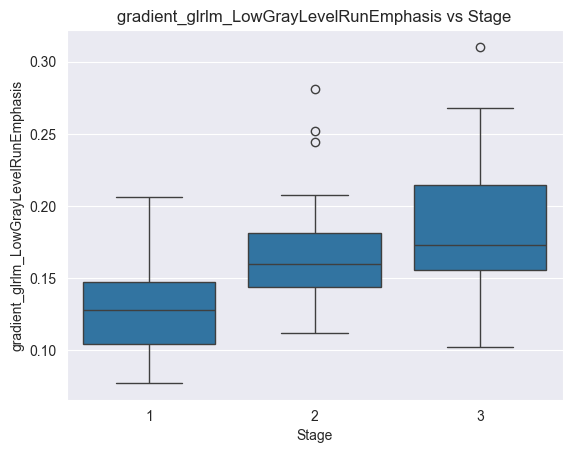

Kruskal-Wallis: gradient_glrlm_RunEntropy -> H = 13.188, p = 0.0014 => Significant: True


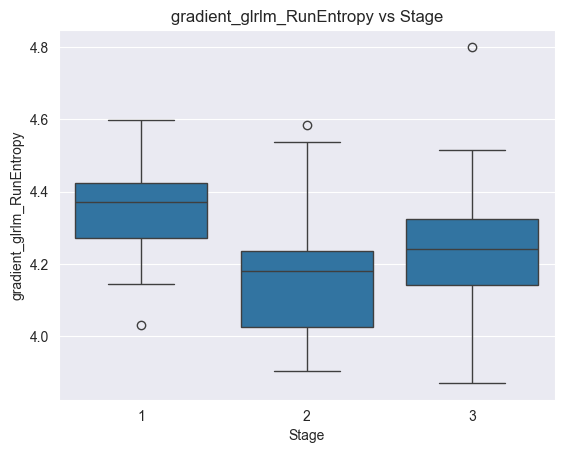

Kruskal-Wallis: gradient_glrlm_RunLengthNonUniformity -> H = 1.122, p = 0.5705 => Significant: False


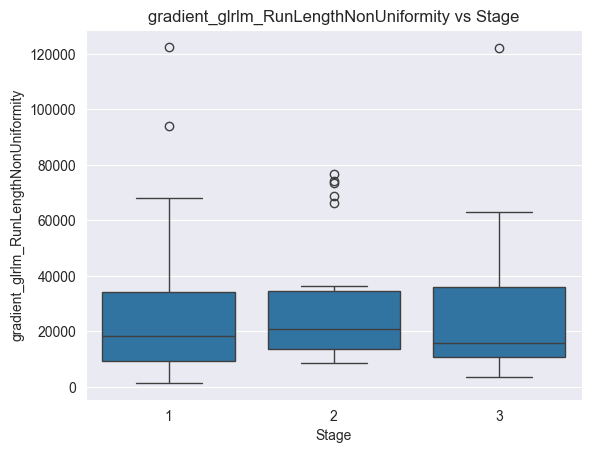

Kruskal-Wallis: gradient_glrlm_RunLengthNonUniformityNormalized -> H = 12.736, p = 0.0017 => Significant: True


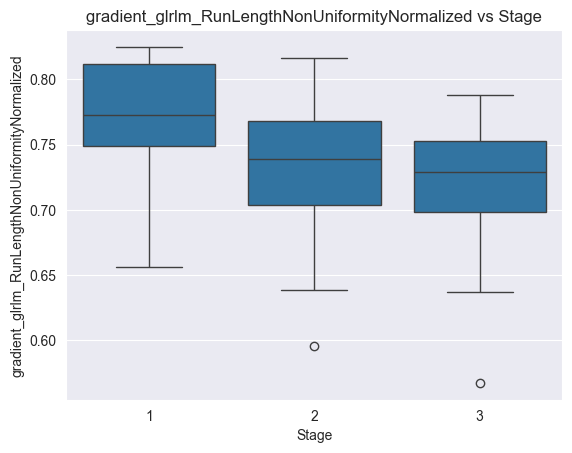

Kruskal-Wallis: gradient_glrlm_RunPercentage -> H = 12.182, p = 0.0023 => Significant: True


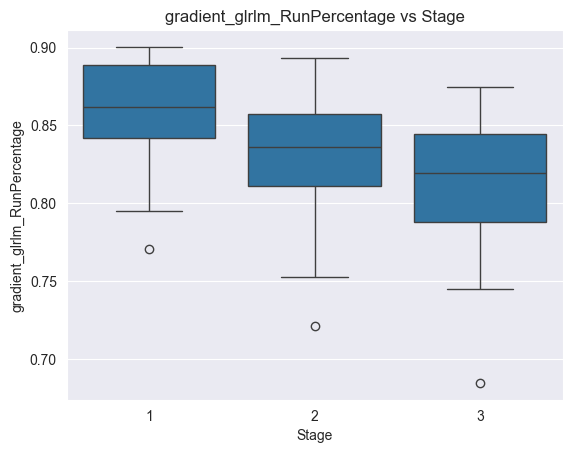

Kruskal-Wallis: gradient_glrlm_RunVariance -> H = 12.070, p = 0.0024 => Significant: True


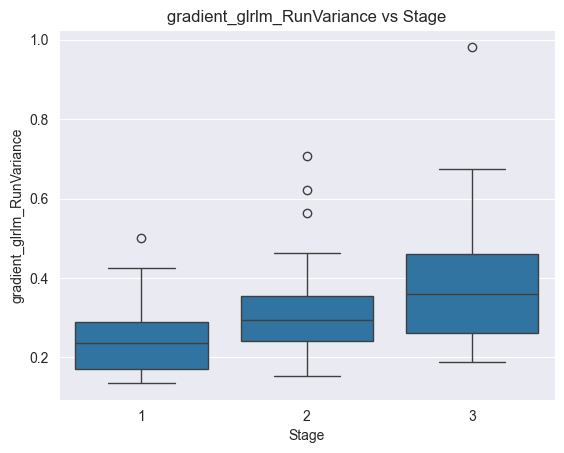

Kruskal-Wallis: gradient_glrlm_ShortRunEmphasis -> H = 12.611, p = 0.0018 => Significant: True


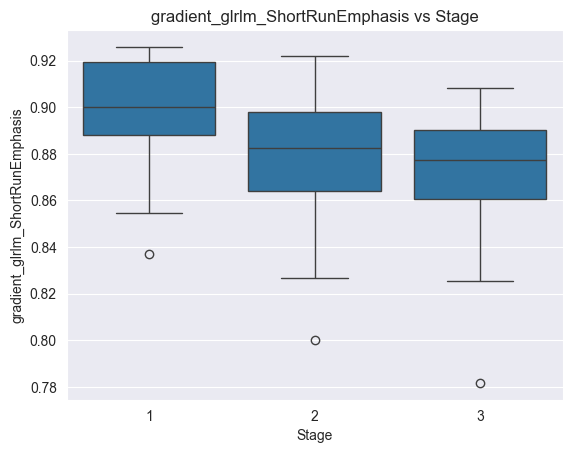

Kruskal-Wallis: gradient_glrlm_ShortRunHighGrayLevelEmphasis -> H = 13.600, p = 0.0011 => Significant: True


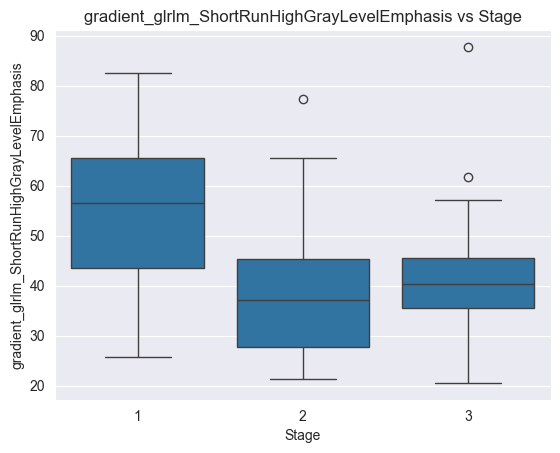

Kruskal-Wallis: gradient_glrlm_ShortRunLowGrayLevelEmphasis -> H = 17.822, p = 0.0001 => Significant: True


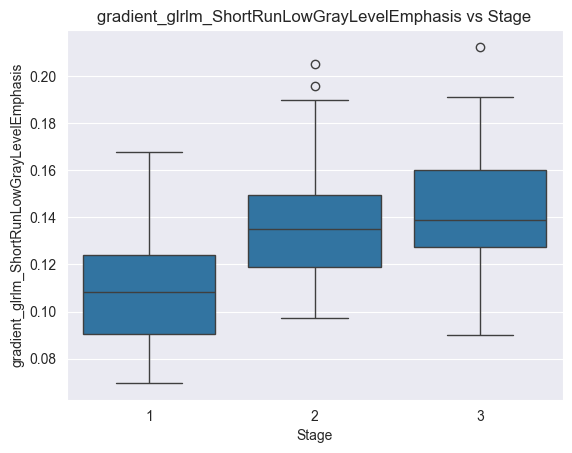

Kruskal-Wallis: gradient_glszm_GrayLevelNonUniformity -> H = 1.090, p = 0.5800 => Significant: False


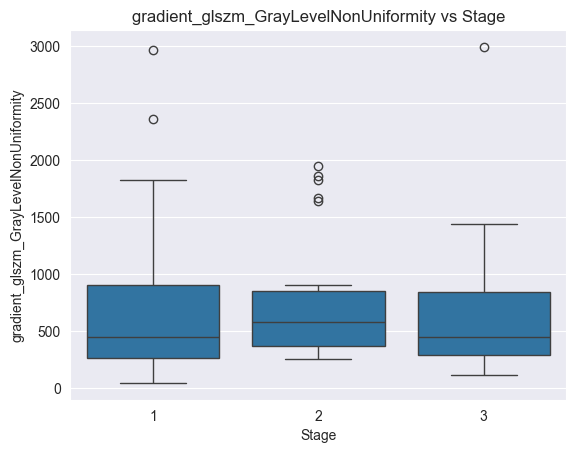

Kruskal-Wallis: gradient_glszm_GrayLevelNonUniformityNormalized -> H = 10.790, p = 0.0045 => Significant: True


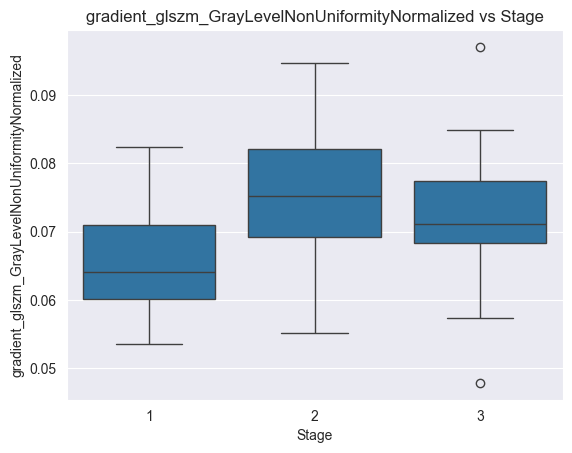

Kruskal-Wallis: gradient_glszm_GrayLevelVariance -> H = 7.533, p = 0.0231 => Significant: True


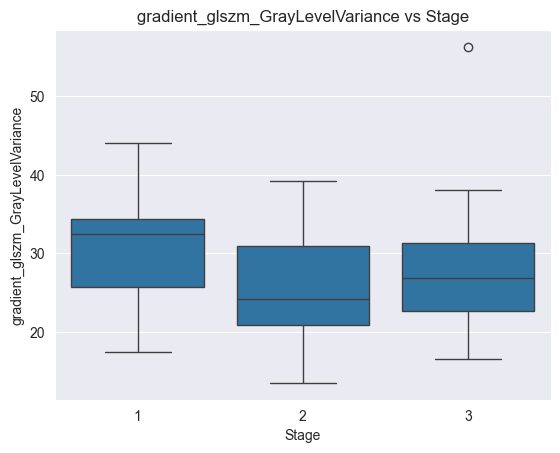

Kruskal-Wallis: gradient_glszm_HighGrayLevelZoneEmphasis -> H = 9.919, p = 0.0070 => Significant: True


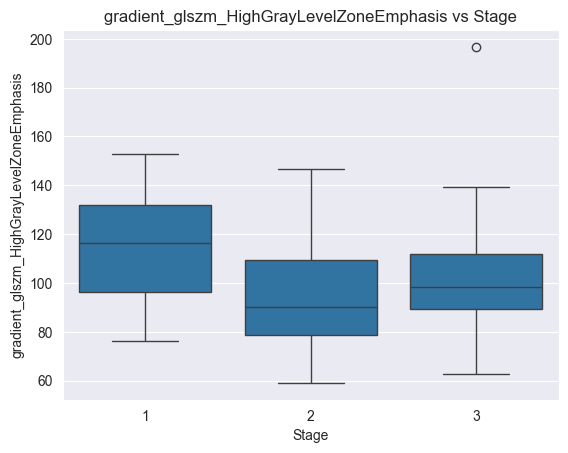

Kruskal-Wallis: gradient_glszm_LargeAreaEmphasis -> H = 4.055, p = 0.1316 => Significant: False


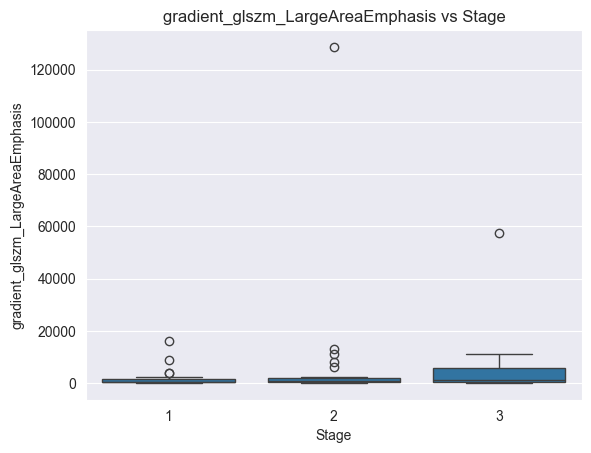

Kruskal-Wallis: gradient_glszm_LargeAreaHighGrayLevelEmphasis -> H = 2.195, p = 0.3337 => Significant: False


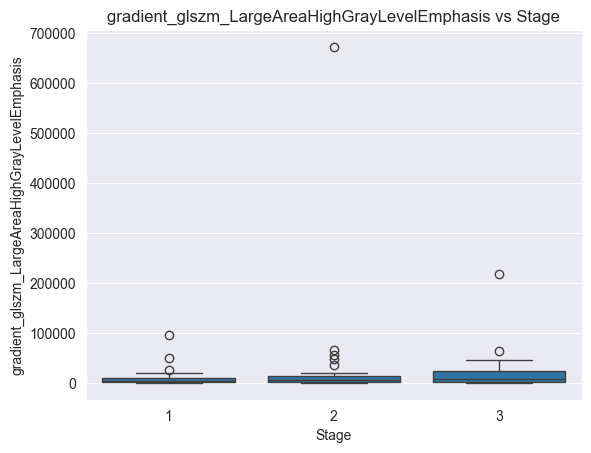

Kruskal-Wallis: gradient_glszm_LargeAreaLowGrayLevelEmphasis -> H = 6.720, p = 0.0347 => Significant: True


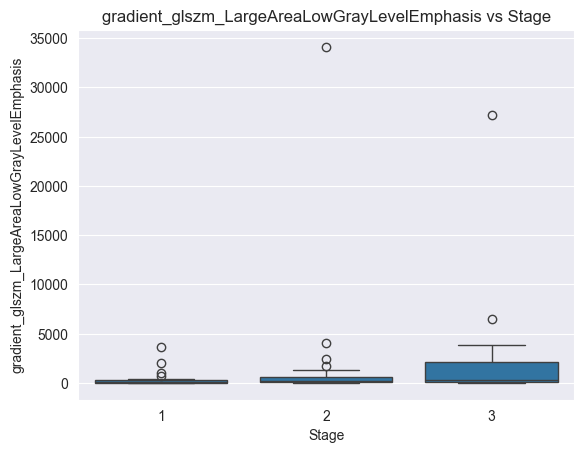

Kruskal-Wallis: gradient_glszm_LowGrayLevelZoneEmphasis -> H = 9.308, p = 0.0095 => Significant: True


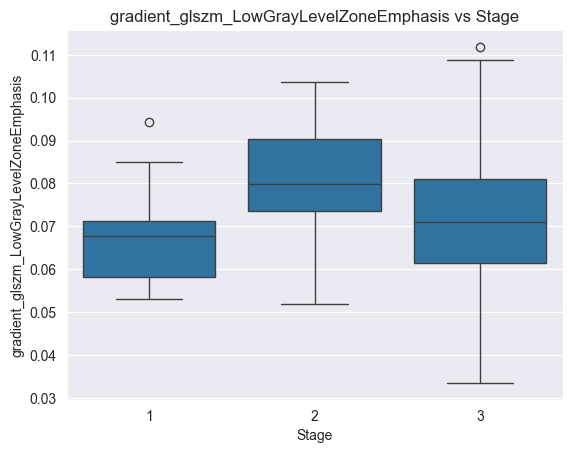

Kruskal-Wallis: gradient_glszm_SizeZoneNonUniformity -> H = 0.307, p = 0.8577 => Significant: False


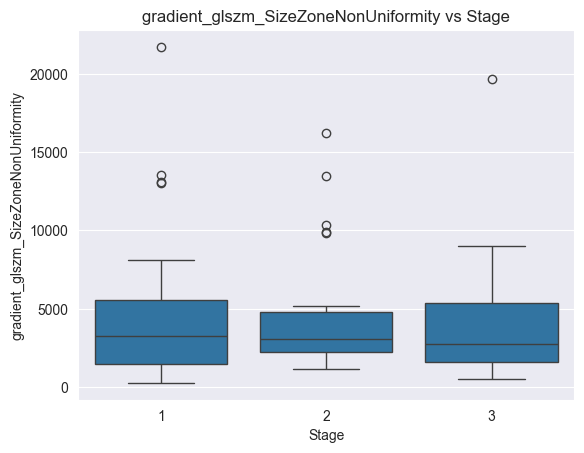

Kruskal-Wallis: gradient_glszm_SizeZoneNonUniformityNormalized -> H = 0.951, p = 0.6216 => Significant: False


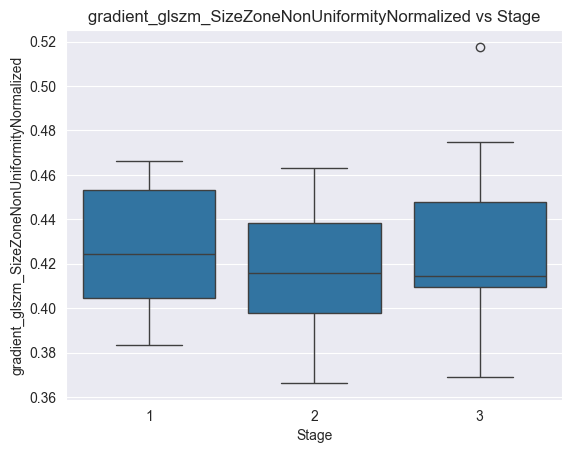

Kruskal-Wallis: gradient_glszm_SmallAreaEmphasis -> H = 0.978, p = 0.6134 => Significant: False


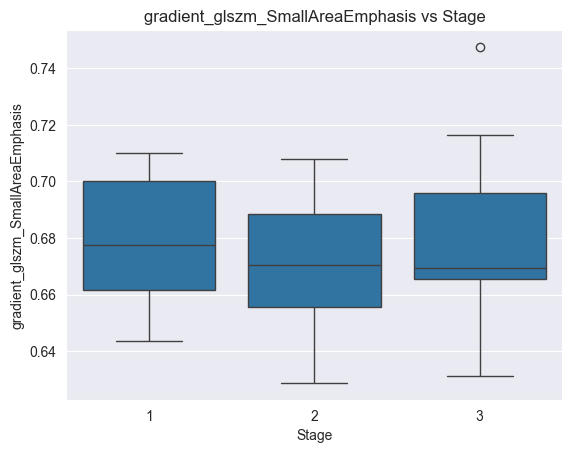

Kruskal-Wallis: gradient_glszm_SmallAreaHighGrayLevelEmphasis -> H = 8.806, p = 0.0122 => Significant: True


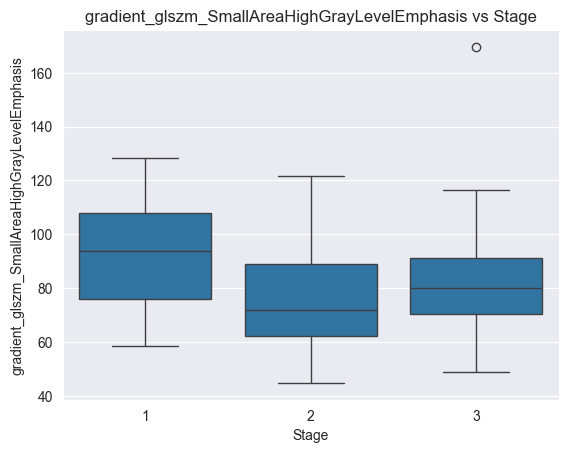

Kruskal-Wallis: gradient_glszm_SmallAreaLowGrayLevelEmphasis -> H = 5.683, p = 0.0583 => Significant: False


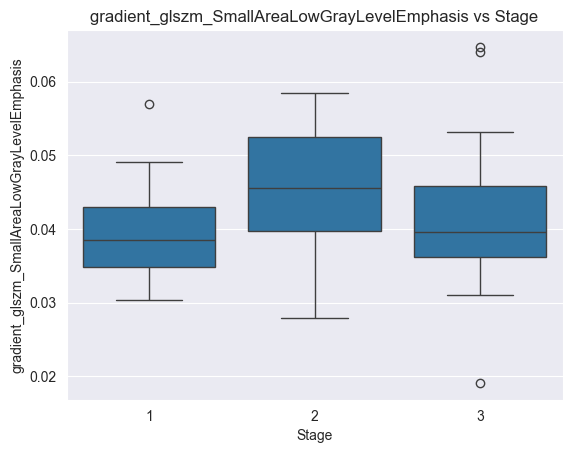

Kruskal-Wallis: gradient_glszm_ZoneEntropy -> H = 7.984, p = 0.0185 => Significant: True


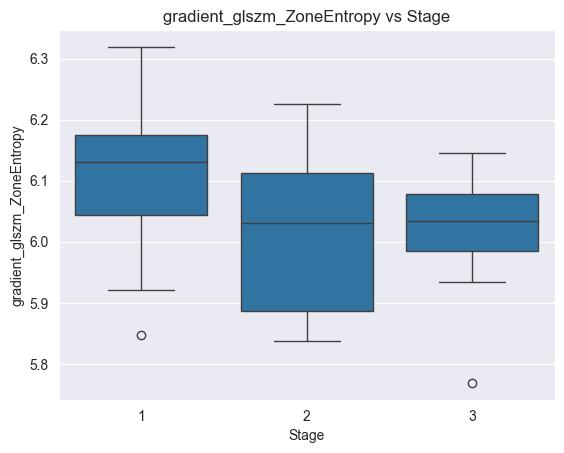

Kruskal-Wallis: gradient_glszm_ZonePercentage -> H = 12.033, p = 0.0024 => Significant: True


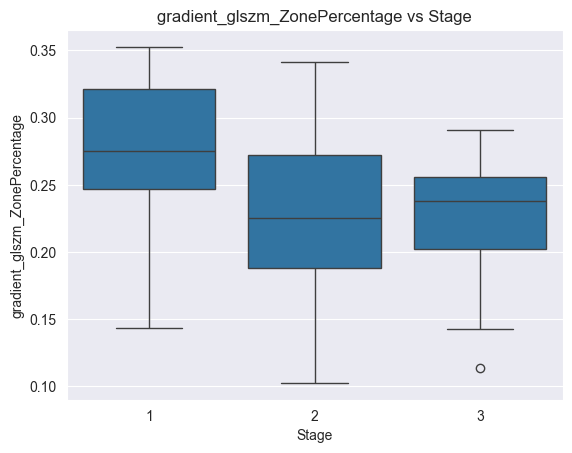

Kruskal-Wallis: gradient_glszm_ZoneVariance -> H = 4.038, p = 0.1328 => Significant: False


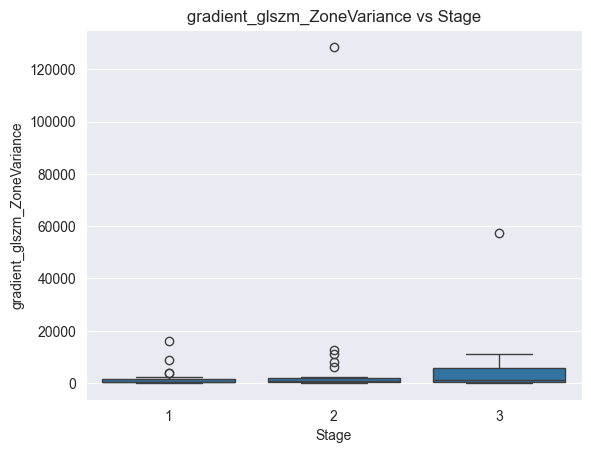

Kruskal-Wallis: gradient_gldm_DependenceEntropy -> H = 8.666, p = 0.0131 => Significant: True


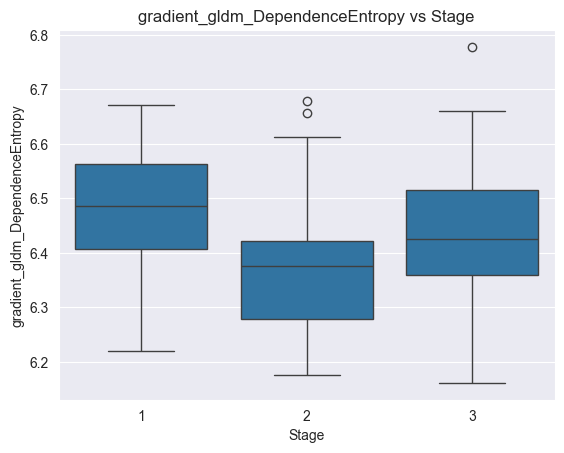

Kruskal-Wallis: gradient_gldm_DependenceNonUniformity -> H = 1.029, p = 0.5977 => Significant: False


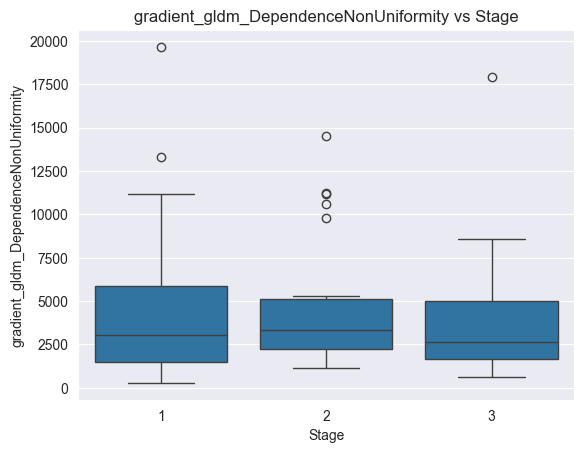

Kruskal-Wallis: gradient_gldm_DependenceNonUniformityNormalized -> H = 12.315, p = 0.0021 => Significant: True


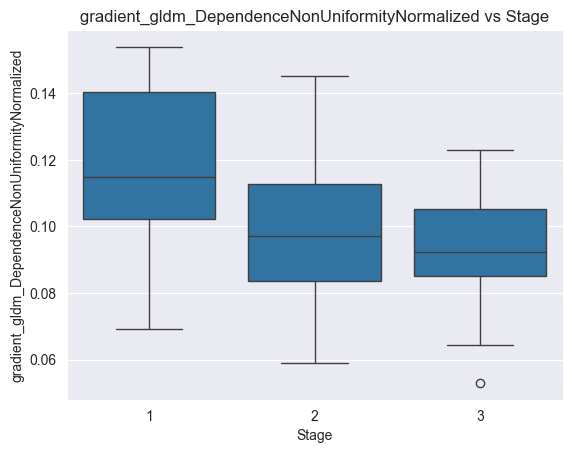

Kruskal-Wallis: gradient_gldm_DependenceVariance -> H = 11.292, p = 0.0035 => Significant: True


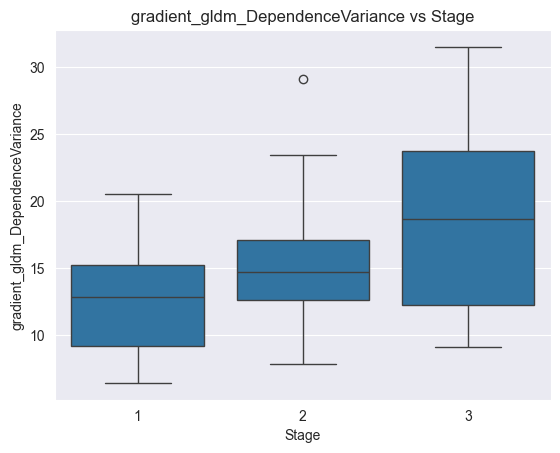

Kruskal-Wallis: gradient_gldm_GrayLevelNonUniformity -> H = 3.029, p = 0.2199 => Significant: False


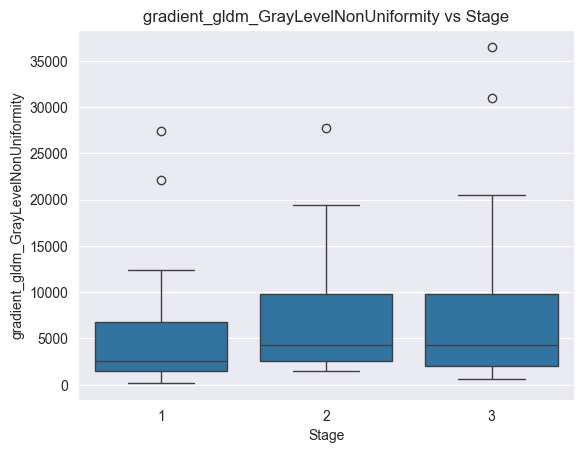

Kruskal-Wallis: gradient_gldm_GrayLevelVariance -> H = 12.515, p = 0.0019 => Significant: True


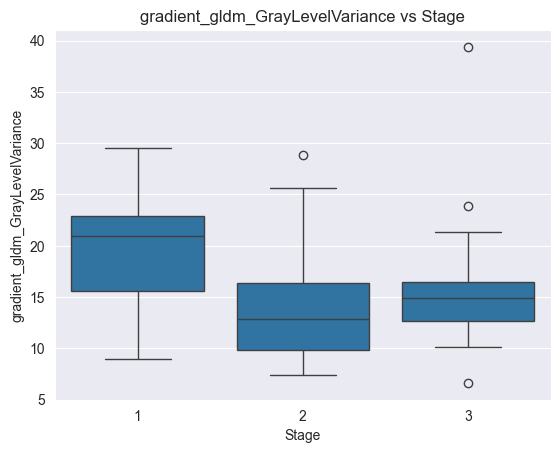

Kruskal-Wallis: gradient_gldm_HighGrayLevelEmphasis -> H = 14.392, p = 0.0007 => Significant: True


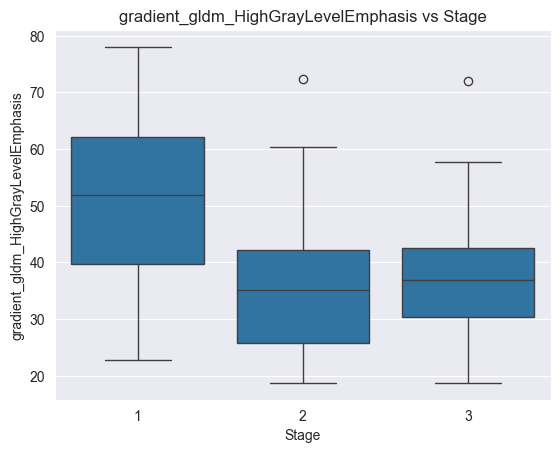

Kruskal-Wallis: gradient_gldm_LargeDependenceEmphasis -> H = 11.641, p = 0.0030 => Significant: True


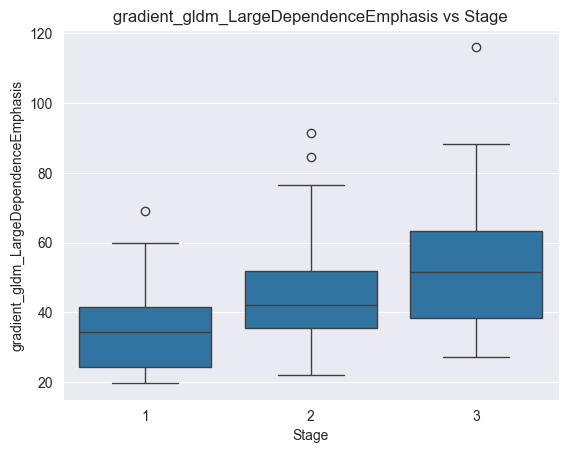

Kruskal-Wallis: gradient_gldm_LargeDependenceHighGrayLevelEmphasis -> H = 5.773, p = 0.0558 => Significant: False


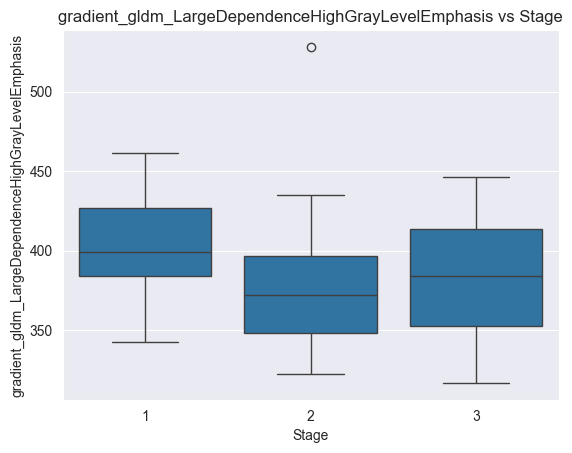

Kruskal-Wallis: gradient_gldm_LargeDependenceLowGrayLevelEmphasis -> H = 15.127, p = 0.0005 => Significant: True


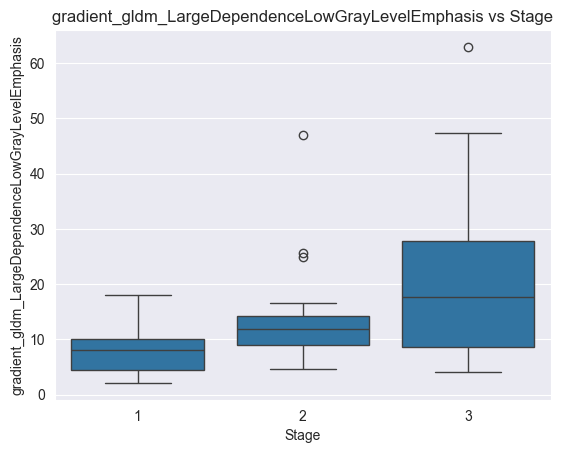

Kruskal-Wallis: gradient_gldm_LowGrayLevelEmphasis -> H = 18.964, p = 0.0001 => Significant: True


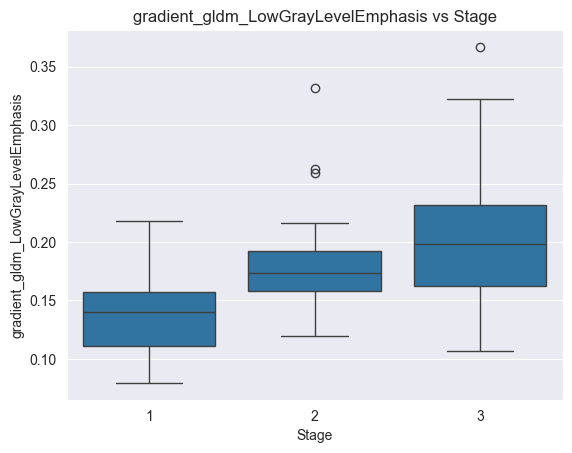

Kruskal-Wallis: gradient_gldm_SmallDependenceEmphasis -> H = 12.543, p = 0.0019 => Significant: True


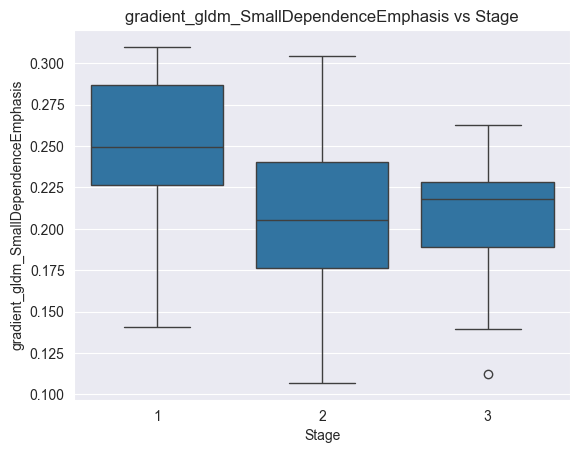

Kruskal-Wallis: gradient_gldm_SmallDependenceHighGrayLevelEmphasis -> H = 12.599, p = 0.0018 => Significant: True


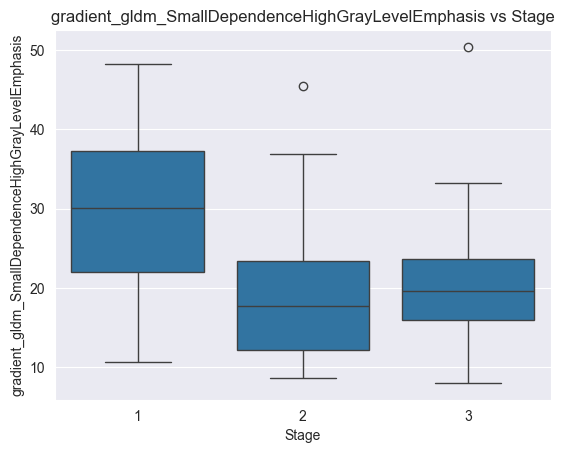

Kruskal-Wallis: gradient_gldm_SmallDependenceLowGrayLevelEmphasis -> H = 2.746, p = 0.2533 => Significant: False


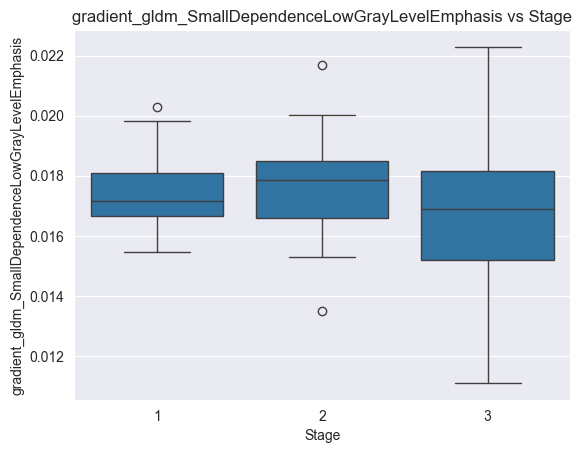

Kruskal-Wallis: gradient_ngtdm_Busyness -> H = 4.237, p = 0.1202 => Significant: False


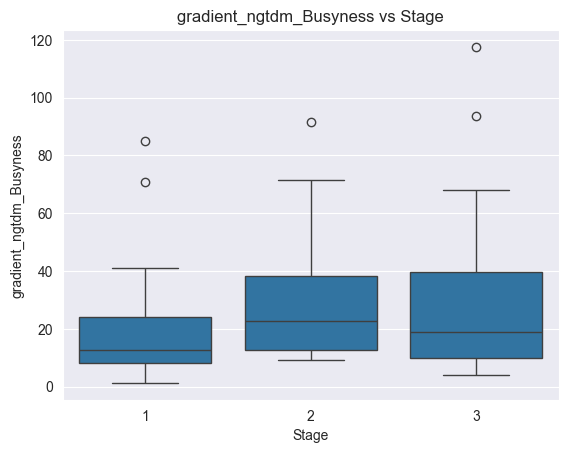

Kruskal-Wallis: gradient_ngtdm_Coarseness -> H = 1.147, p = 0.5635 => Significant: False


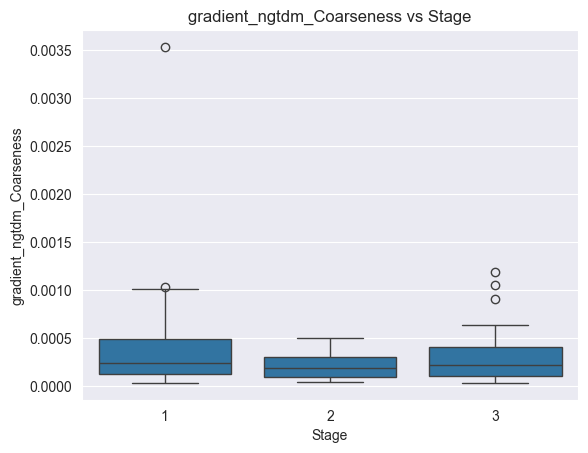

Kruskal-Wallis: gradient_ngtdm_Complexity -> H = 5.029, p = 0.0809 => Significant: False


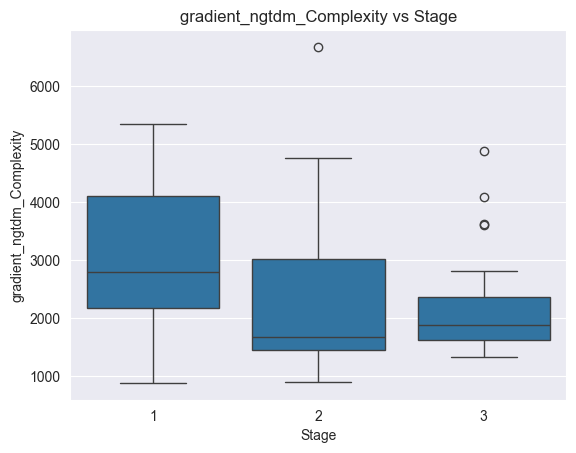

Kruskal-Wallis: gradient_ngtdm_Contrast -> H = 7.599, p = 0.0224 => Significant: True


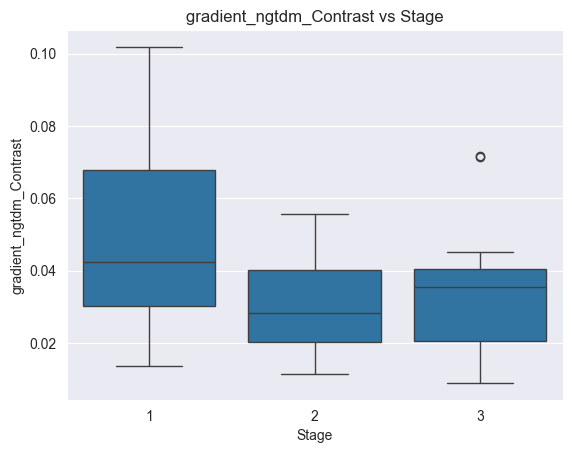

Kruskal-Wallis: gradient_ngtdm_Strength -> H = 3.184, p = 0.2035 => Significant: False


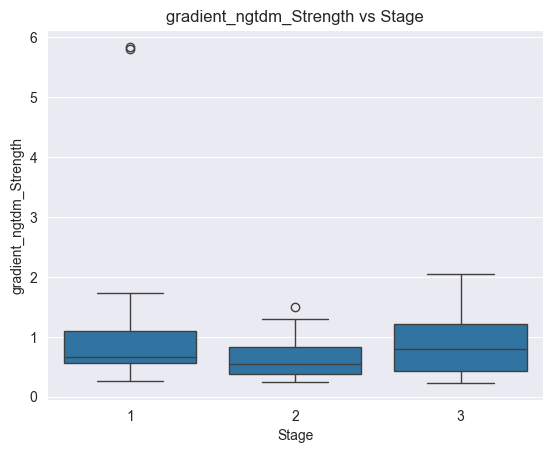

In [5]:
pd.set_option('future.no_silent_downcasting', True)
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = features_df.select_dtypes(include=['number']).columns

for feature in numeric_features:

    data = pd.concat([features_df[feature], clinical_df['Stage']], axis=1).dropna()
    stage1 = data[data['Stage'] == 1][feature].dropna()
    stage2 = data[data['Stage'] == 2][feature].dropna()
    stage3 = data[data['Stage'] == 3][feature].dropna()

    stat, p_value = kruskal(stage1, stage2, stage3)
    print(f"Kruskal-Wallis: {feature} -> H = {stat:.3f}, p = {p_value:.4f} => Significant: {p_value < 0.05}")

    # VISUALIZATION
    sns.boxplot(x='Stage', y=feature, data=data)
    plt.xlabel('Stage')
    plt.ylabel(feature)
    plt.title(f'{feature} vs Stage')
    plt.show()